<a href="https://colab.research.google.com/github/elfadilisafae0972encg-dot/Version-Finale/blob/main/code_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data

### Subtask:
Load the 'New York Stock Exchange-data.csv' file into a pandas DataFrame and display its initial information (head, info, describe) to understand the dataset structure and data types.


**Reasoning**:
Load the specified CSV file into a pandas DataFrame and display its initial information (head, info, describe) as requested in the subtask.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/New York Stock Exchange-data.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

First 5 rows of the DataFrame:
   Unnamed: 0 Ticker Symbol Period Ending  Accounts Payable  \
0           0           AAL    2012-12-31      3.068000e+09   
1           1           AAL    2013-12-31      4.975000e+09   
2           2           AAL    2014-12-31      4.668000e+09   
3           3           AAL    2015-12-31      5.102000e+09   
4           4           AAP    2012-12-29      2.409453e+09   

   Accounts Receivable  Add'l income/expense items  After Tax ROE  \
0         -222000000.0               -1.961000e+09           23.0   
1          -93000000.0               -2.723000e+09           67.0   
2         -160000000.0               -1.500000e+08          143.0   
3          352000000.0               -7.080000e+08          135.0   
4          -89482000.0                6.000000e+05           32.0   

   Capital Expenditures  Capital Surplus  Cash Ratio  ...  \
0         -1.888000e+09     4.695000e+09        53.0  ...   
1         -3.114000e+09     1.059200e+10        75.0 

## Initial Data Inspection and Formatting

### Subtask:
Perform an initial inspection to identify data types, check for consistency, and convert relevant columns (e.g., 'Date' column) to appropriate formats if necessary.


**Reasoning**:
I will perform the requested data cleaning and type conversion steps, including removing the redundant 'Unnamed: 0' column, converting 'Period Ending' to datetime, and handling the 'For Year' column by addressing unlikely values and converting it to an appropriate integer type.



In [ ]:
import numpy as np

# 1. Remove the 'Unnamed: 0' column
df = df.drop('Unnamed: 0', axis=1)
print("Dropped 'Unnamed: 0' column.")

# 2. Convert the 'Period Ending' column to datetime
df['Period Ending'] = pd.to_datetime(df['Period Ending'])
print("Converted 'Period Ending' to datetime.")

# 3. Examine and handle the 'For Year' column
# Replace years that are clearly erroneous (e.g., before a plausible financial reporting era like 1900)
# with NaN before converting to integer to allow for imputation later if needed.
df['For Year'] = df['For Year'].apply(lambda x: x if pd.isna(x) or x >= 1900 else np.nan)

# Convert 'For Year' to nullable integer type to accommodate NaN values
df['For Year'] = df['For Year'].astype('Int64')
print("Handled 'For Year' column by converting to nullable integer and replacing unlikely years.")

print("\nDataFrame after initial inspection and formatting:")
print(df.head())
print("\nConcise summary of the DataFrame after changes:")
df.info()

Dropped 'Unnamed: 0' column.
Converted 'Period Ending' to datetime.
Handled 'For Year' column by converting to nullable integer and replacing unlikely years.

DataFrame after initial inspection and formatting:
  Ticker Symbol Period Ending  Accounts Payable  Accounts Receivable  \
0           AAL    2012-12-31      3.068000e+09         -222000000.0   
1           AAL    2013-12-31      4.975000e+09          -93000000.0   
2           AAL    2014-12-31      4.668000e+09         -160000000.0   
3           AAL    2015-12-31      5.102000e+09          352000000.0   
4           AAP    2012-12-29      2.409453e+09          -89482000.0   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0               -1.961000e+09           23.0         -1.888000e+09   
1               -2.723000e+09           67.0         -3.114000e+09   
2               -1.500000e+08          143.0         -5.311000e+09   
3               -7.080000e+08          135.0         -6.151000e+09   
4      

## Handle Duplicates

### Subtask:
Identify and remove any duplicate rows present in the dataset to ensure data uniqueness.


**Reasoning**:
The subtask requires identifying and removing duplicate rows, then verifying the removal. This can be achieved by first checking for duplicates, then dropping them and resetting the index, and finally confirming no duplicates remain.



In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

# Remove duplicate rows, keeping the first occurrence
df.drop_duplicates(inplace=True)

# Reset index after dropping duplicates
df.reset_index(drop=True, inplace=True)

print("Duplicate rows removed and index reset.")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"New shape of the DataFrame: {df.shape}")

Number of duplicate rows before removal: 0
Duplicate rows removed and index reset.
Number of duplicate rows after removal: 0
New shape of the DataFrame: (1781, 78)


## Impute Missing Values



**Reasoning**:
First, I'll identify all columns with missing values and then impute the specified numerical columns ('Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', 'Estimated Shares Outstanding') with their respective medians.



In [ ]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing values for specified numerical columns with their median
columns_to_impute_median = ['Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', 'Estimated Shares Outstanding', 'Quick Ratio']

for col in columns_to_impute_median:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"Imputed missing values in '{col}' with median: {median_value}")

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDataFrame info after imputation:")
df.info()

Missing values before imputation:
Quick Ratio    299
dtype: int64
Imputed missing values in 'Cash Ratio' with median: 41.0
Imputed missing values in 'Current Ratio' with median: 152.0
Imputed missing values in 'For Year' with median: 2014.0
Imputed missing values in 'Earnings Per Share' with median: 2.81
Imputed missing values in 'Estimated Shares Outstanding' with median: 292940893.611
Imputed missing values in 'Quick Ratio' with median: 115.0

Missing values after imputation:
Series([], dtype: int64)

DataFrame info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 78 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Ticker Symbol                                        1781 non-null   object        
 1   Period Ending                                        1781 non-null   datetime64

## Encode Categorical Variables

### Subtask:
Identify categorical columns and apply suitable encoding techniques.


**Reasoning**:
I will identify the 'Ticker Symbol' column, apply one-hot encoding using `pd.get_dummies()`, concatenate the new columns with the DataFrame, and drop the original 'Ticker Symbol' column.



In [ ]:
print("Identifying categorical columns...")
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {list(categorical_cols)}")

if 'Ticker Symbol' in categorical_cols:
    print("Applying one-hot encoding to 'Ticker Symbol'...")
    # Apply one-hot encoding
    df_encoded = pd.get_dummies(df, columns=['Ticker Symbol'], prefix='Ticker')
    print("One-hot encoding applied to 'Ticker Symbol'.")
else:
    df_encoded = df.copy()
    print("'Ticker Symbol' column not found or not categorical. Skipping encoding.")

df = df_encoded

print("\nDataFrame after encoding 'Ticker Symbol':")
print(df.head())
print("\nConcise summary of the DataFrame after encoding:")
df.info()

Identifying categorical columns...
Categorical columns identified: ['Ticker Symbol']
Applying one-hot encoding to 'Ticker Symbol'...
One-hot encoding applied to 'Ticker Symbol'.

DataFrame after encoding 'Ticker Symbol':
  Period Ending  Accounts Payable  Accounts Receivable  \
0    2012-12-31      3.068000e+09         -222000000.0   
1    2013-12-31      4.975000e+09          -93000000.0   
2    2014-12-31      4.668000e+09         -160000000.0   
3    2015-12-31      5.102000e+09          352000000.0   
4    2012-12-29      2.409453e+09          -89482000.0   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0               -1.961000e+09           23.0         -1.888000e+09   
1               -2.723000e+09           67.0         -3.114000e+09   
2               -1.500000e+08          143.0         -5.311000e+09   
3               -7.080000e+08          135.0         -6.151000e+09   
4                6.000000e+05           32.0         -2.711820e+08   

   Capita

## Scale Numerical Data

### Subtask:
Identify numerical columns. Apply either Standardization (Z-score scaling) or Normalization (Min-Max scaling) to bring numerical features to a similar scale, choosing the method based on data distribution and modeling requirements.


### Reasoning:
To scale the numerical columns, I will identify all columns with a numerical data type (float64, Int64), excluding 'Period Ending'. I will then apply `StandardScaler` to these columns, which is suitable for many machine learning models as it centers the data around zero and scales it to unit variance. After scaling, I will replace the original numerical columns with their scaled versions and display the updated DataFrame's head and descriptive statistics to verify the changes.

**Reasoning**:
I will import `StandardScaler` from `sklearn.preprocessing`, identify numerical columns excluding 'Period Ending', apply standardization to these columns, update the DataFrame with the scaled values, and then display the head and descriptive statistics to verify the scaling.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns, excluding 'Period Ending'
# Use ._get_numeric_data() for a more robust way to select only truly numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()

# Exclude 'Period Ending' if it somehow made it into numerical_cols (though it's datetime now)
if 'Period Ending' in numerical_cols:
    numerical_cols.remove('Period Ending')

print(f"Numerical columns to scale: {numerical_cols[:5]}... (total {len(numerical_cols)})\n")

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical columns scaled using StandardScaler.")

print("\nDataFrame after scaling numerical features (first 5 rows):")
print(df.head())

print("\nDescriptive statistics after scaling:")
print(df.describe())

Numerical columns to scale: ['Accounts Payable', 'Accounts Receivable', "Add'l income/expense items", 'After Tax ROE', 'Capital Expenditures']... (total 76)

Numerical columns scaled using StandardScaler.

DataFrame after scaling numerical features (first 5 rows):
  Period Ending  Accounts Payable  Accounts Receivable  \
0    2012-12-31         -0.114212            -0.209591   
1    2013-12-31          0.021455            -0.038972   
2    2014-12-31         -0.000385            -0.127588   
3    2015-12-31          0.030490             0.549600   
4    2012-12-29         -0.161061            -0.034319   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0                   -2.965270      -0.088093             -0.213511   
1                   -4.078293       0.100055             -0.625041   
2                   -0.320015       0.425038             -1.362505   
3                   -1.135063       0.390829             -1.644467   
4                   -0.100040      -

## Review Preprocessed Data

### Subtask:
Display the first few rows and summary statistics of the preprocessed DataFrame to confirm that all cleaning, imputation, encoding, and scaling steps have been applied correctly.


**Reasoning**:
To confirm that all preprocessing steps have been applied correctly, I will display the first few rows, a concise summary, and descriptive statistics of the DataFrame.



In [ ]:
print("First 5 rows of the preprocessed DataFrame:")
print(df.head())

print("\nConcise summary of the preprocessed DataFrame:")
df.info()

print("\nDescriptive statistics of the preprocessed DataFrame:")
print(df.describe())

First 5 rows of the preprocessed DataFrame:
  Period Ending  Accounts Payable  Accounts Receivable  \
0    2012-12-31         -0.114212            -0.209591   
1    2013-12-31          0.021455            -0.038972   
2    2014-12-31         -0.000385            -0.127588   
3    2015-12-31          0.030490             0.549600   
4    2012-12-29         -0.161061            -0.034319   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0                   -2.965270      -0.088093             -0.213511   
1                   -4.078293       0.100055             -0.625041   
2                   -0.320015       0.425038             -1.362505   
3                   -1.135063       0.390829             -1.644467   
4                   -0.100040      -0.049608              0.329205   

   Capital Surplus  Cash Ratio  Cash and Cash Equivalents  \
0        -0.057935   -0.168302                  -0.132424   
1         0.462239    0.065443                  -0.116864   
2  

## Exploratory Data Analysis (EDA)

### Subtask:
Visualize the distributions of key numerical features using histograms and boxplots to understand their spread, central tendency, and identify outliers.

**Reasoning**:
To understand the distribution of numerical features, I will generate histograms for a few selected scaled columns. Histograms provide a visual representation of the data's frequency distribution, helping us to identify its shape, center, and spread, as well as the presence of multiple modes or unusual patterns. I'll use `matplotlib.pyplot` and `seaborn` for better visualization.

Generating histograms for selected numerical columns...


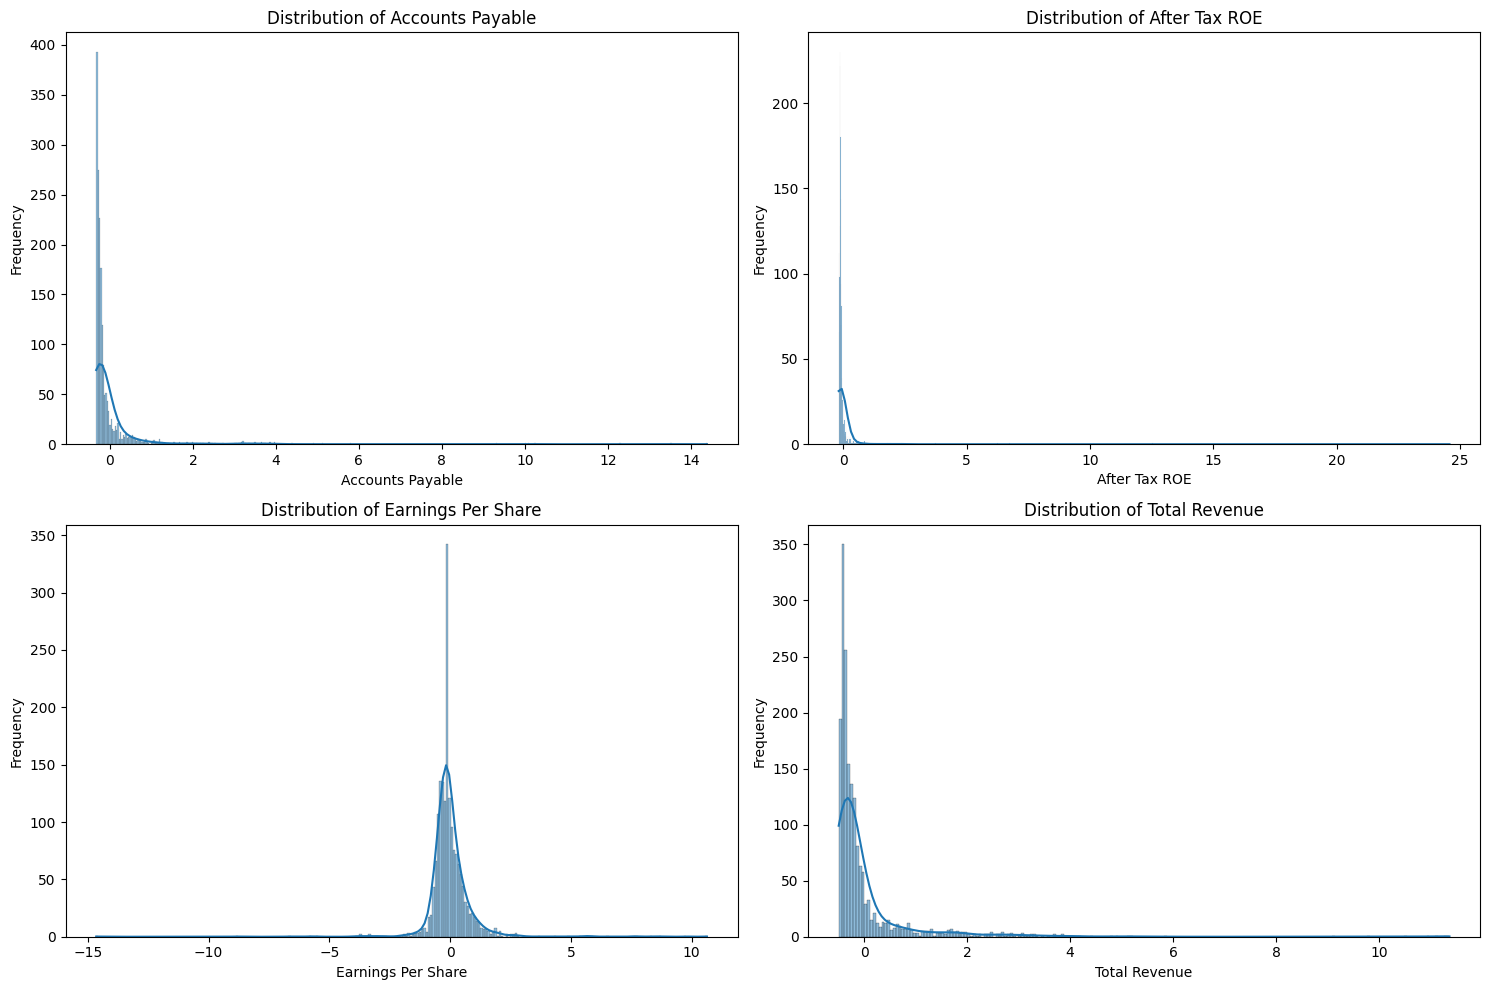

Histograms generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few key numerical columns for histogram visualization
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

print("Generating histograms for selected numerical columns...")

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True) # kde=True adds a kernel density estimate line
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histograms generated.")

**Reasoning**:
Next, I will generate boxplots for the same selected scaled numerical columns. Boxplots are excellent for visualizing the five-number summary (minimum, first quartile, median, third quartile, and maximum) and identifying potential outliers, which are plotted as individual points beyond the 'whiskers'.

Generating boxplots for selected numerical columns...


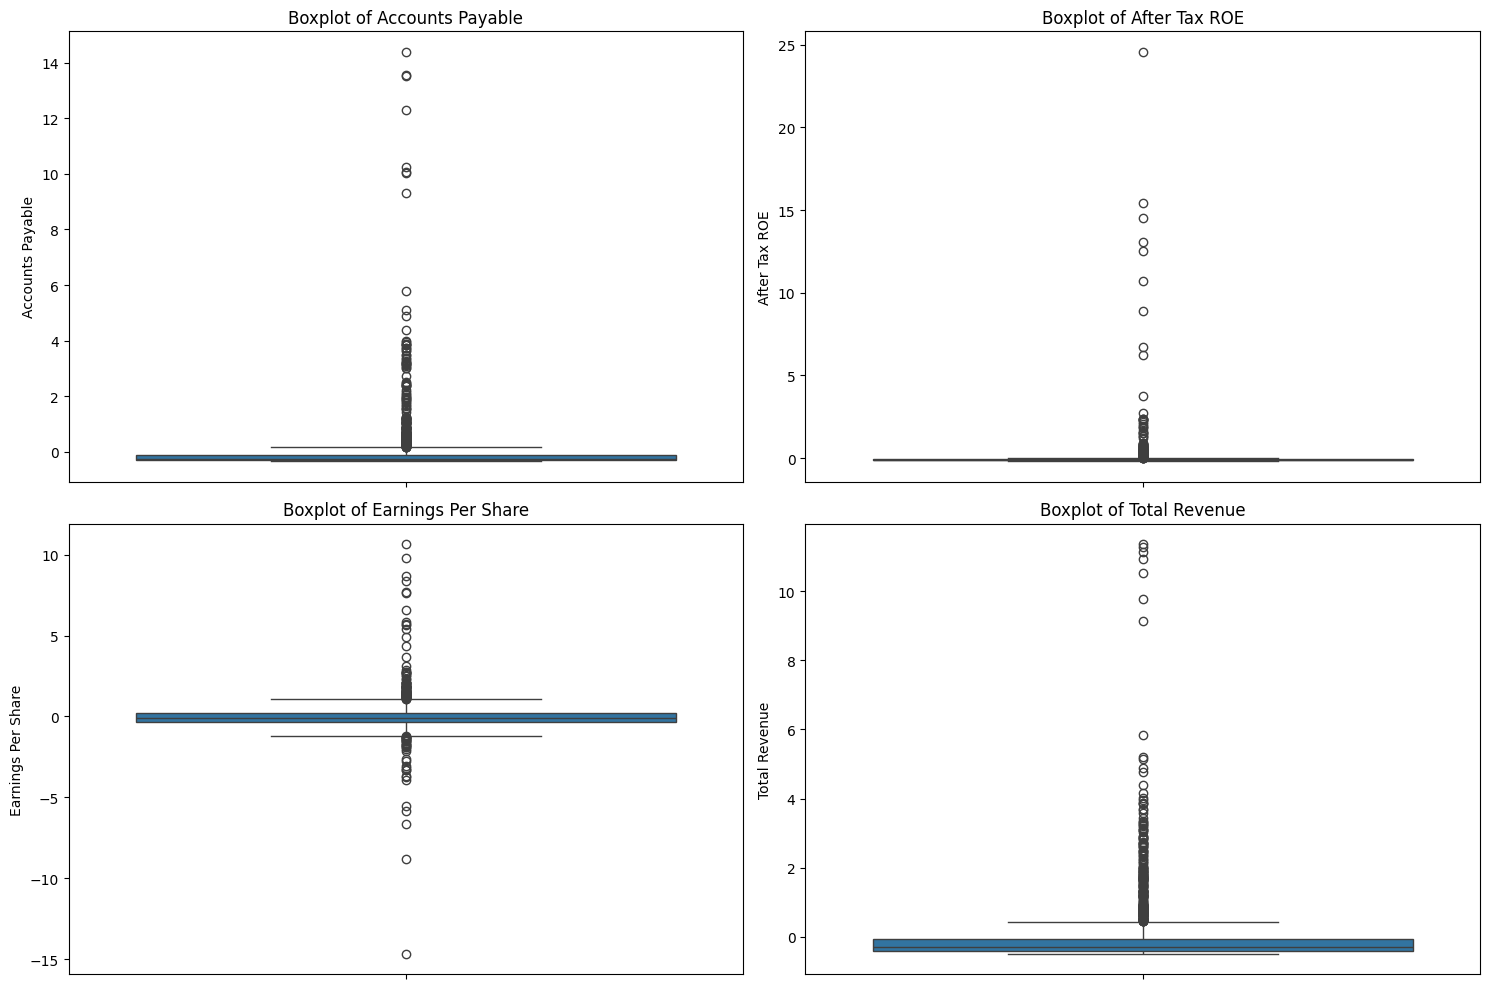

Boxplots generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the same selected numerical columns for boxplot visualization
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

print("Generating boxplots for selected numerical columns...")

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col]) # Boxplot along the y-axis
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("Boxplots generated.")

### Subtask:
Perform a Correlation Analysis (Heatmap) to visualize relationships between numerical features.

**Reasoning**:
To understand the linear relationships between the numerical variables, I will compute the correlation matrix of the DataFrame. A heatmap will then be generated to visually represent these correlations, making it easier to spot highly correlated features which might indicate multicollinearity or strong dependencies. Given the large number of features, I'll select a subset of the most relevant numerical columns or display only a portion of the heatmap to maintain readability.

Calculating correlation matrix...
Generating heatmap for the correlation matrix (top 10 correlations shown for brevity)...


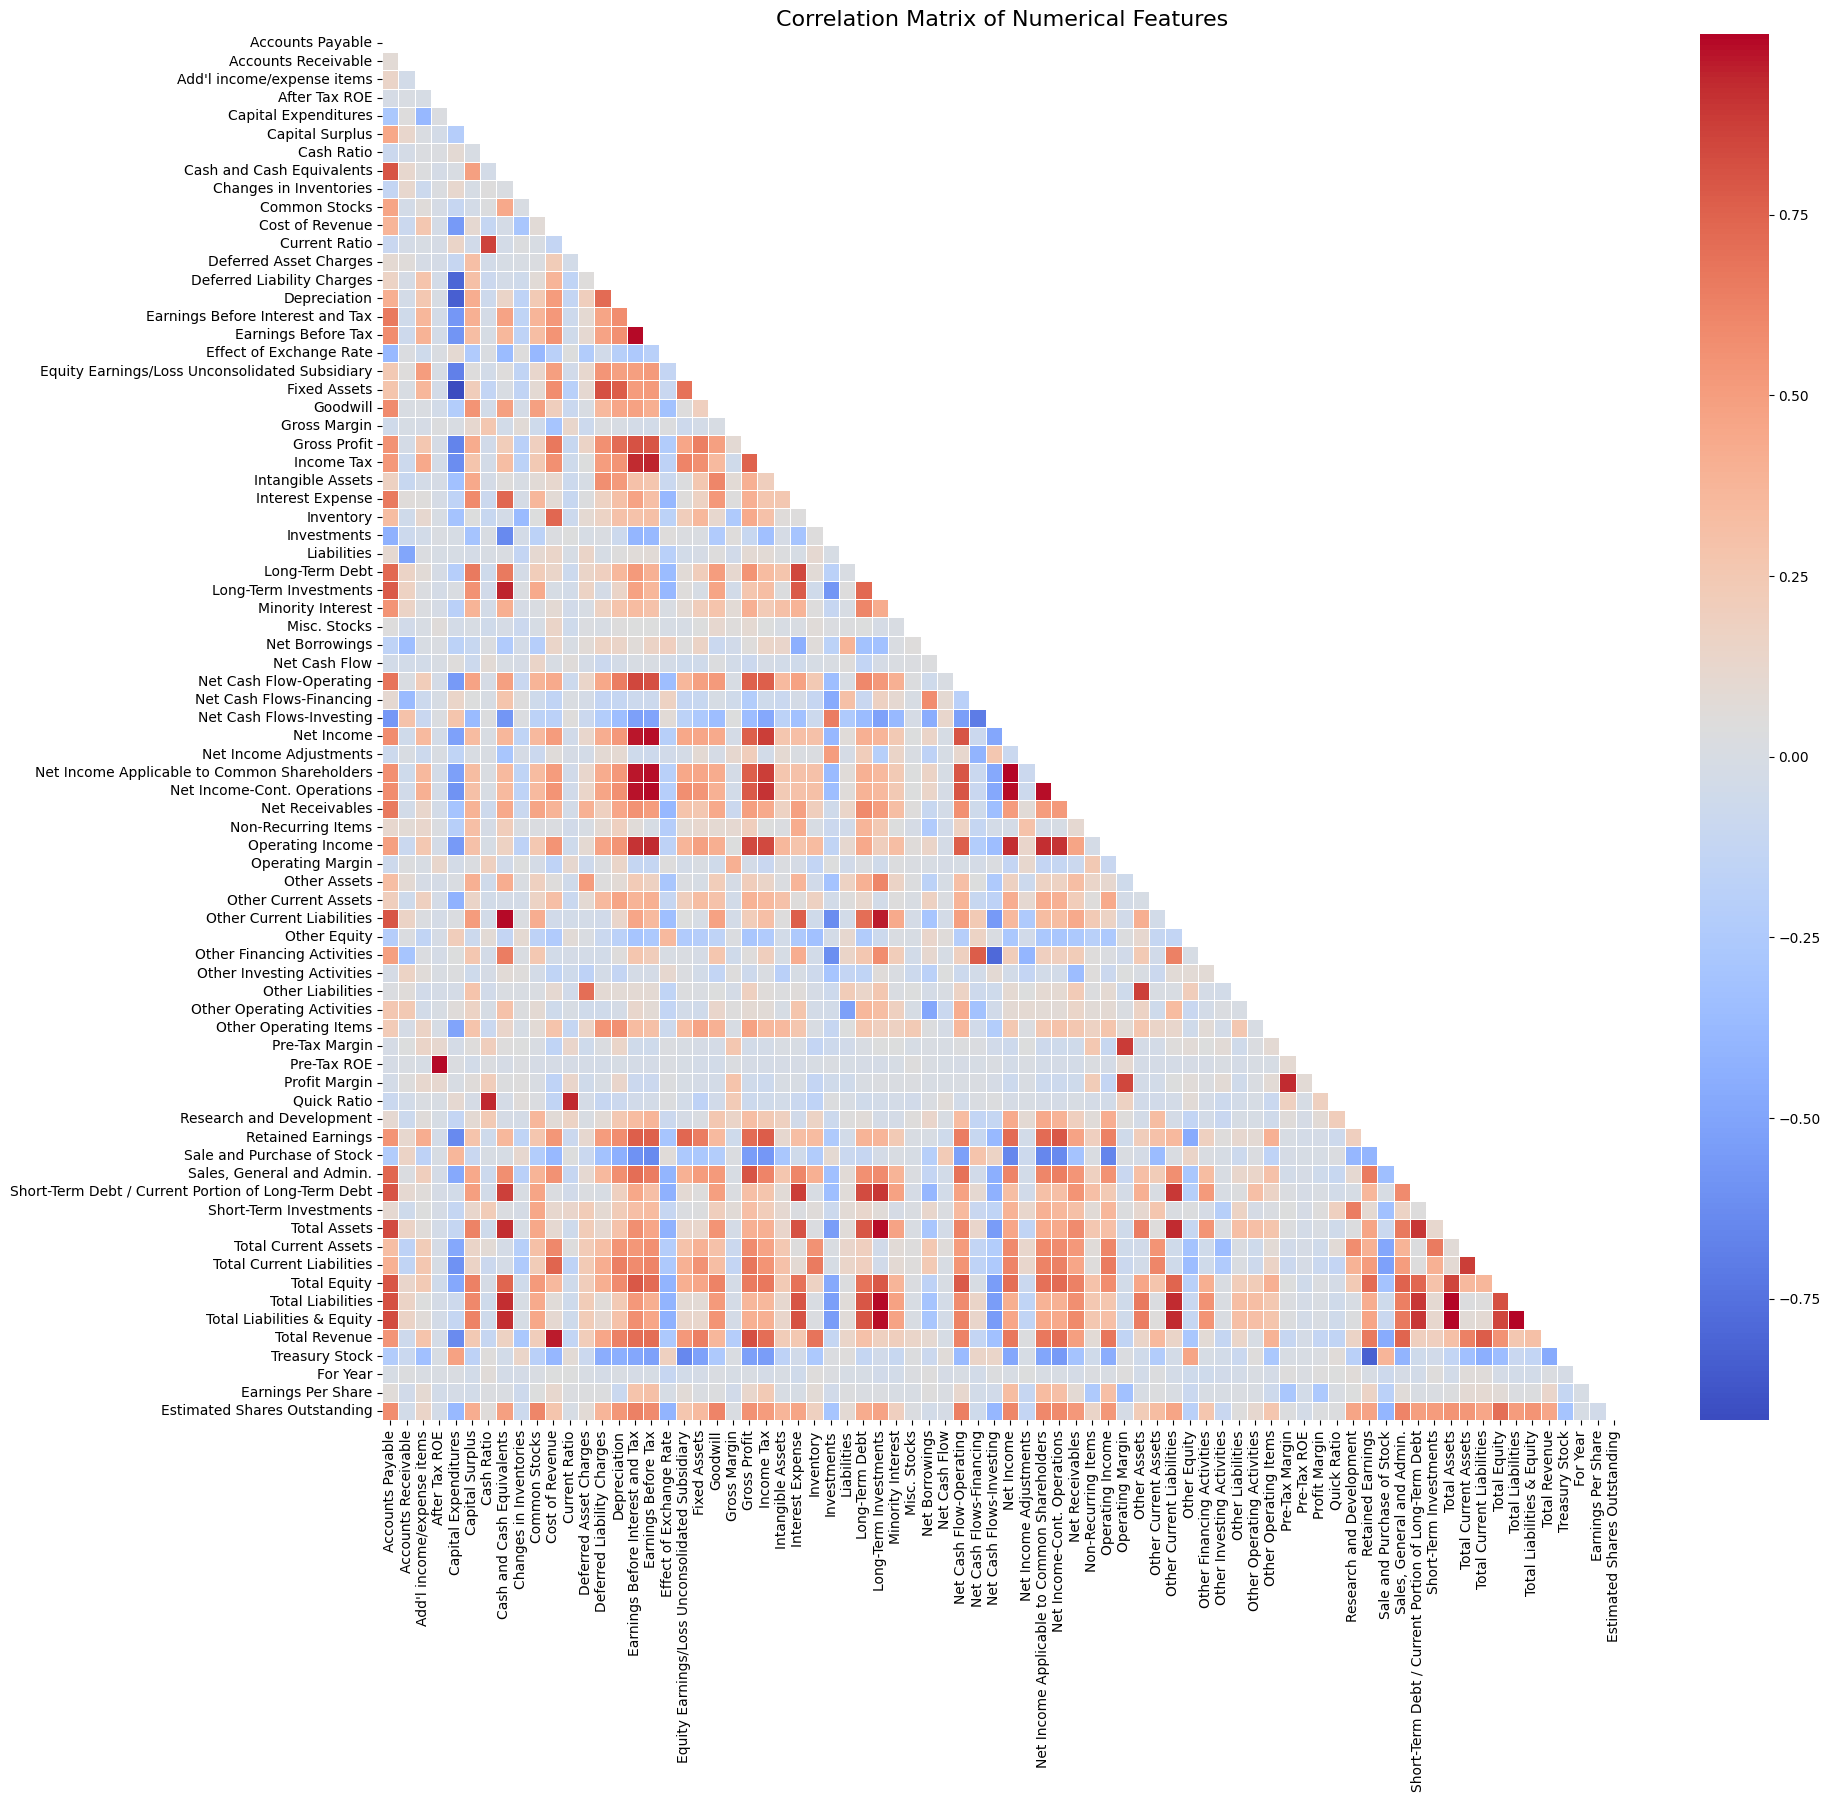

Correlation heatmap generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating correlation matrix...")

# Exclude 'Period Ending' from numerical columns for correlation calculation as it's datetime.
# Also, boolean columns from one-hot encoding are technically numerical (0s and 1s) but
# might not be meaningful for a general correlation heatmap with many other financial metrics.
# Let's focus on the original float64 columns and the Int64 'For Year' column.

# Identify numerical columns (original financial metrics and 'For Year')
# Filtering out the boolean (one-hot encoded) columns for a more focused heatmap
numerical_features_for_corr = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()

# Remove one-hot encoded columns from the list, assuming they start with 'Ticker_'
numerical_features_for_corr = [col for col in numerical_features_for_corr if not col.startswith('Ticker_')]

# Remove 'Period Ending' if it somehow made it in
if 'Period Ending' in numerical_features_for_corr:
    numerical_features_for_corr.remove('Period Ending')

# Calculate the correlation matrix
correlation_matrix = df[numerical_features_for_corr].corr()

print("Generating heatmap for the correlation matrix (top 10 correlations shown for brevity)...")

# For better visualization due to many columns, let's look at a subset of highly correlated features
# or simplify the plot.
# Alternatively, we can show only the absolute top correlations.

# Create a mask for the upper triangle
mask = np.triu(correlation_matrix)

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix,
            mask=mask, # Apply the mask
            annot=False, # Set to True for showing values, but can be too crowded for many columns
            cmap='coolwarm', # Color map
            fmt=".2f", # Format annotation values
            linewidths=.5 # Add lines between cells
           )
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

print("Correlation heatmap generated.")

## Feature Engineering

### Subtask:
Create new relevant variables as the third step of exploratory data analysis.

**Reasoning**:
I will extract temporal features such as 'Year', 'Month', 'Day', and 'Quarter' from the 'Period Ending' column. Additionally, I will create a boolean feature 'Is_End_Of_Year' to indicate if the period ending is December 31st, which can be significant for financial reporting cycles. These new features will enrich the dataset and potentially reveal new patterns related to time, which is crucial for financial data.

In [ ]:
# 1. Extract Year, Month, Day, and Quarter from 'Period Ending'
df['Year'] = df['Period Ending'].dt.year
df['Month'] = df['Period Ending'].dt.month
df['Day'] = df['Period Ending'].dt.day
df['Quarter'] = df['Period Ending'].dt.quarter

# 2. Create a boolean feature for end of year reporting
df['Is_End_Of_Year'] = (df['Period Ending'].dt.month == 12) & (df['Period Ending'].dt.day == 31)

print("New features created from 'Period Ending' column:")
print(df[['Period Ending', 'Year', 'Month', 'Day', 'Quarter', 'Is_End_Of_Year']].head())

print("\nConcise summary of the DataFrame after feature engineering:")
df.info()

New features created from 'Period Ending' column:
  Period Ending  Year  Month  Day  Quarter  Is_End_Of_Year
0    2012-12-31  2012     12   31        4            True
1    2013-12-31  2013     12   31        4            True
2    2014-12-31  2014     12   31        4            True
3    2015-12-31  2015     12   31        4            True
4    2012-12-29  2012     12   29        4           False

Concise summary of the DataFrame after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Columns: 530 entries, Period Ending to Is_End_Of_Year
dtypes: bool(449), datetime64[ns](1), float64(76), int32(4)
memory usage: 1.8 MB


## Identify Target Variable

### Subtask:
Please specify which column from our preprocessed DataFrame you would like to predict. Based on the financial nature of the dataset and the numerical columns, we will assume a regression task for now. For example, popular choices might be 'Earnings Per Share', 'After Tax ROE', or 'Total Revenue'.


For this regression task, we will choose **'Earnings Per Share'** as our target variable (y). This financial metric is crucial for investors and analysts, as it indicates a company's profitability and is a key factor in stock valuation.

Our goal will be to predict 'Earnings Per Share' based on the other available features in the dataset.

## Split Data into Training and Testing Sets

### Subtask:
Split the preprocessed DataFrame into features (X) and the chosen target variable (y). Then, divide these into training and testing sets to prepare for model training and evaluation.


### Reasoning:
To prepare the data for machine learning, I will first separate the features (X) from the target variable (y), which is 'Earnings Per Share'. The 'Period Ending' column will be excluded from the features as it is a datetime object and not directly usable for most models in its current form. Then, I will use `train_test_split` to divide the data into training and testing sets, ensuring a consistent split for reproducibility with `random_state`.

**Reasoning**:
I will import `train_test_split` and then split the DataFrame into features (X) and the target variable (y, 'Earnings Per Share'), excluding the 'Period Ending' column, and finally divide these into training and testing sets.



In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop(columns=['Earnings Per Share', 'Period Ending'])
y = df['Earnings Per Share']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of features (X): (1781, 528)
Shape of target (y): (1781,)

Data split into training and testing sets:
X_train shape: (1424, 528)
X_test shape: (357, 528)
y_train shape: (1424,)
y_test shape: (357,)


## Train and Evaluate Linear Regression Model

### Subtask:
Train a Linear Regression model on the training data and evaluate its performance on the test set using relevant regression metrics (e.g., R-squared, Mean Absolute Error, Mean Squared Error).


**Reasoning**:
To train and evaluate the Linear Regression model, I will import the necessary classes and functions from `sklearn`, instantiate the model, train it on the training data, make predictions on the test data, and then calculate and print the Mean Absolute Error, Mean Squared Error, and R-squared score.



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Training Linear Regression model...")

# Instantiate the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

print("Making predictions on the test set...")

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

print("Evaluating model performance...")

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print the evaluation metrics
print(f"\n--- Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"R-squared (R2) Score: {r2_lr:.4f}")

Training Linear Regression model...
Making predictions on the test set...
Evaluating model performance...

--- Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 0.3507
Mean Squared Error (MSE): 0.5748
R-squared (R2) Score: 0.5083


## Train and Evaluate Gradient Boosting Regressor Model

### Subtask:
Train a Gradient Boosting Regressor model, another powerful ensemble technique, on the training data and evaluate its performance on the test set using the chosen regression metrics.


**Reasoning**:
To train and evaluate the Gradient Boosting Regressor model, I will import the necessary classes and functions, instantiate the model, train it on the training data, make predictions on the test data, and then calculate and print the Mean Absolute Error, Mean Squared Error, and R-squared score.



In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Training Gradient Boosting Regressor model...")

# Instantiate the Gradient Boosting Regressor model
# Setting a random_state for reproducibility
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model using the training data
gbr_model.fit(X_train, y_train)

print("Making predictions on the test set...")

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

print("Evaluating model performance...")

# Calculate evaluation metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print the evaluation metrics
print(f"\n--- Gradient Boosting Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_gbr:.4f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.4f}")
print(f"R-squared (R2) Score: {r2_gbr:.4f}")

Training Gradient Boosting Regressor model...
Making predictions on the test set...
Evaluating model performance...

--- Gradient Boosting Regressor Model Evaluation ---
Mean Absolute Error (MAE): 0.2053
Mean Squared Error (MSE): 0.2746
R-squared (R2) Score: 0.7651


## Compare Model Performance

### Subtask:
Compare the evaluation metrics (R-squared, MAE, MSE) of the Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor models to determine which one performs best on this dataset.


## Compare Model Performance

To determine the best-performing model, we will compare the evaluation metrics (Mean Absolute Error, Mean Squared Error, and R-squared) for the Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor models.

**Reasoning**:
To systematically compare the performance of the three models, I will create a pandas DataFrame that summarizes the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) scores for Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. This table will make it easy to visually identify the best and worst performing models for each metric.



In [ ]:
import pandas as pd

# Create a dictionary to store the evaluation metrics for each model
performance_data = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'MAE': [mae_lr, mae_rf, mae_gbr],
    'MSE': [mse_lr, mse_rf, mse_gbr],
    'R2 Score': [r2_lr, r2_rf, r2_gbr]
}

# Create a DataFrame from the performance data
performance_df = pd.DataFrame(performance_data)

print("Model Performance Comparison:")
print(performance_df.to_markdown(index=False))

# Identify the best performing model for each metric
best_mae_model = performance_df.loc[performance_df['MAE'].idxmin()]
best_mse_model = performance_df.loc[performance_df['MSE'].idxmin()]
best_r2_model = performance_df.loc[performance_df['R2 Score'].idxmax()]

print(f"\nBest model for MAE (lowest): {best_mae_model['Model']} with MAE = {best_mae_model['MAE']:.4f}")
print(f"Best model for MSE (lowest): {best_mse_model['Model']} with MSE = {best_mse_model['MSE']:.4f}")
print(f"Best model for R2 Score (highest): {best_r2_model['Model']} with R2 Score = {best_r2_model['R2 Score']:.4f}")

print("\nBased on the R-squared score, the Gradient Boosting Regressor model performs best with the highest R2 score.")

Model Performance Comparison:
| Model                       |      MAE |      MSE |   R2 Score |
|:----------------------------|---------:|---------:|-----------:|
| Linear Regression           | 0.35066  | 0.574765 |   0.508322 |
| Random Forest Regressor     | 0.150015 | 0.282331 |   0.758482 |
| Gradient Boosting Regressor | 0.205294 | 0.274554 |   0.765135 |

Best model for MAE (lowest): Random Forest Regressor with MAE = 0.1500
Best model for MSE (lowest): Gradient Boosting Regressor with MSE = 0.2746
Best model for R2 Score (highest): Gradient Boosting Regressor with R2 Score = 0.7651

Based on the R-squared score, the Gradient Boosting Regressor model performs best with the highest R2 score.


# Task
Implement cross-validation for robust evaluation of the Gradient Boosting Regressor model on the dataset, then define a hyperparameter grid for the model, optimize its hyperparameters using GridSearchCV, evaluate the optimized model on the test set, and finally summarize the findings and highlight any improvements in model performance.

## Implement Cross-Validation for Robust Evaluation

### Subtask:
Apply K-Fold Cross-Validation to one of the better-performing models (e.g., Gradient Boosting Regressor) to obtain a more robust and reliable estimate of its performance across different subsets of the data. This will help assess the model's generalization capabilities more accurately than a single train-test split.


**Reasoning**:
To implement K-Fold Cross-Validation, I will import the necessary classes, instantiate the Gradient Boosting Regressor model and KFold cross-validation strategy, then use `cross_val_score` to evaluate the model and print the mean and standard deviation of the R-squared scores.



In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

print("Applying K-Fold Cross-Validation...")

# Instantiate a GradientBoostingRegressor model
gbr_model_cv = GradientBoostingRegressor(random_state=42)

# Define K-fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get R-squared scores for each fold
r2_scores_cv = cross_val_score(gbr_model_cv, X, y, cv=kf, scoring='r2')

print("Cross-validation R-squared scores for each fold:")
for i, score in enumerate(r2_scores_cv):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMean R-squared across all folds: {np.mean(r2_scores_cv):.4f}")
print(f"Standard deviation of R-squared across all folds: {np.std(r2_scores_cv):.4f}")


Applying K-Fold Cross-Validation...
Cross-validation R-squared scores for each fold:
Fold 1: 0.7652
Fold 2: 0.8356
Fold 3: 0.7259
Fold 4: 0.8480
Fold 5: 0.4880

Mean R-squared across all folds: 0.7325
Standard deviation of R-squared across all folds: 0.1303


# Task
Define a dictionary `param_grid` containing hyperparameters and their corresponding values for the Gradient Boosting Regressor model, including `n_estimators`, `learning_rate`, and `max_depth`.

## Define Hyperparameter Grid

### Subtask:
Define a dictionary of hyperparameters and their potential values for the Gradient Boosting Regressor model to be used in GridSearchCV.


**Reasoning**:
To define the hyperparameter grid, I will create a dictionary named `param_grid` and populate it with the specified `n_estimators`, `learning_rate`, and `max_depth` values as lists.



In [ ]:
print("Defining hyperparameter grid for Gradient Boosting Regressor...")

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5]  # Maximum depth of the individual regression estimators
}

print("Hyperparameter grid defined:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

Defining hyperparameter grid for Gradient Boosting Regressor...
Hyperparameter grid defined:
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.1, 0.2]
  max_depth: [3, 4, 5]


import matplotlib.pyplot as plt
import seaborn as sns

# Select a few key numerical columns for boxplot visualization
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

print("Generating boxplots for selected numerical columns...")

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col]) # Boxplot along the y-axis
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("Boxplots generated.")

## Generate Correlation Heatmap

### Subtask:
Generate a correlation heatmap for the numerical features to show relationships between variables. This plot will be included in the report's EDA section.


**Reasoning**:
To generate the correlation heatmap as requested, I will implement the instructions provided: import plotting libraries, calculate the correlation matrix for selected numerical features, create a mask for the upper triangle, and then use `seaborn.heatmap` to visualize the correlations with specified parameters for readability.



Generating correlation heatmap...


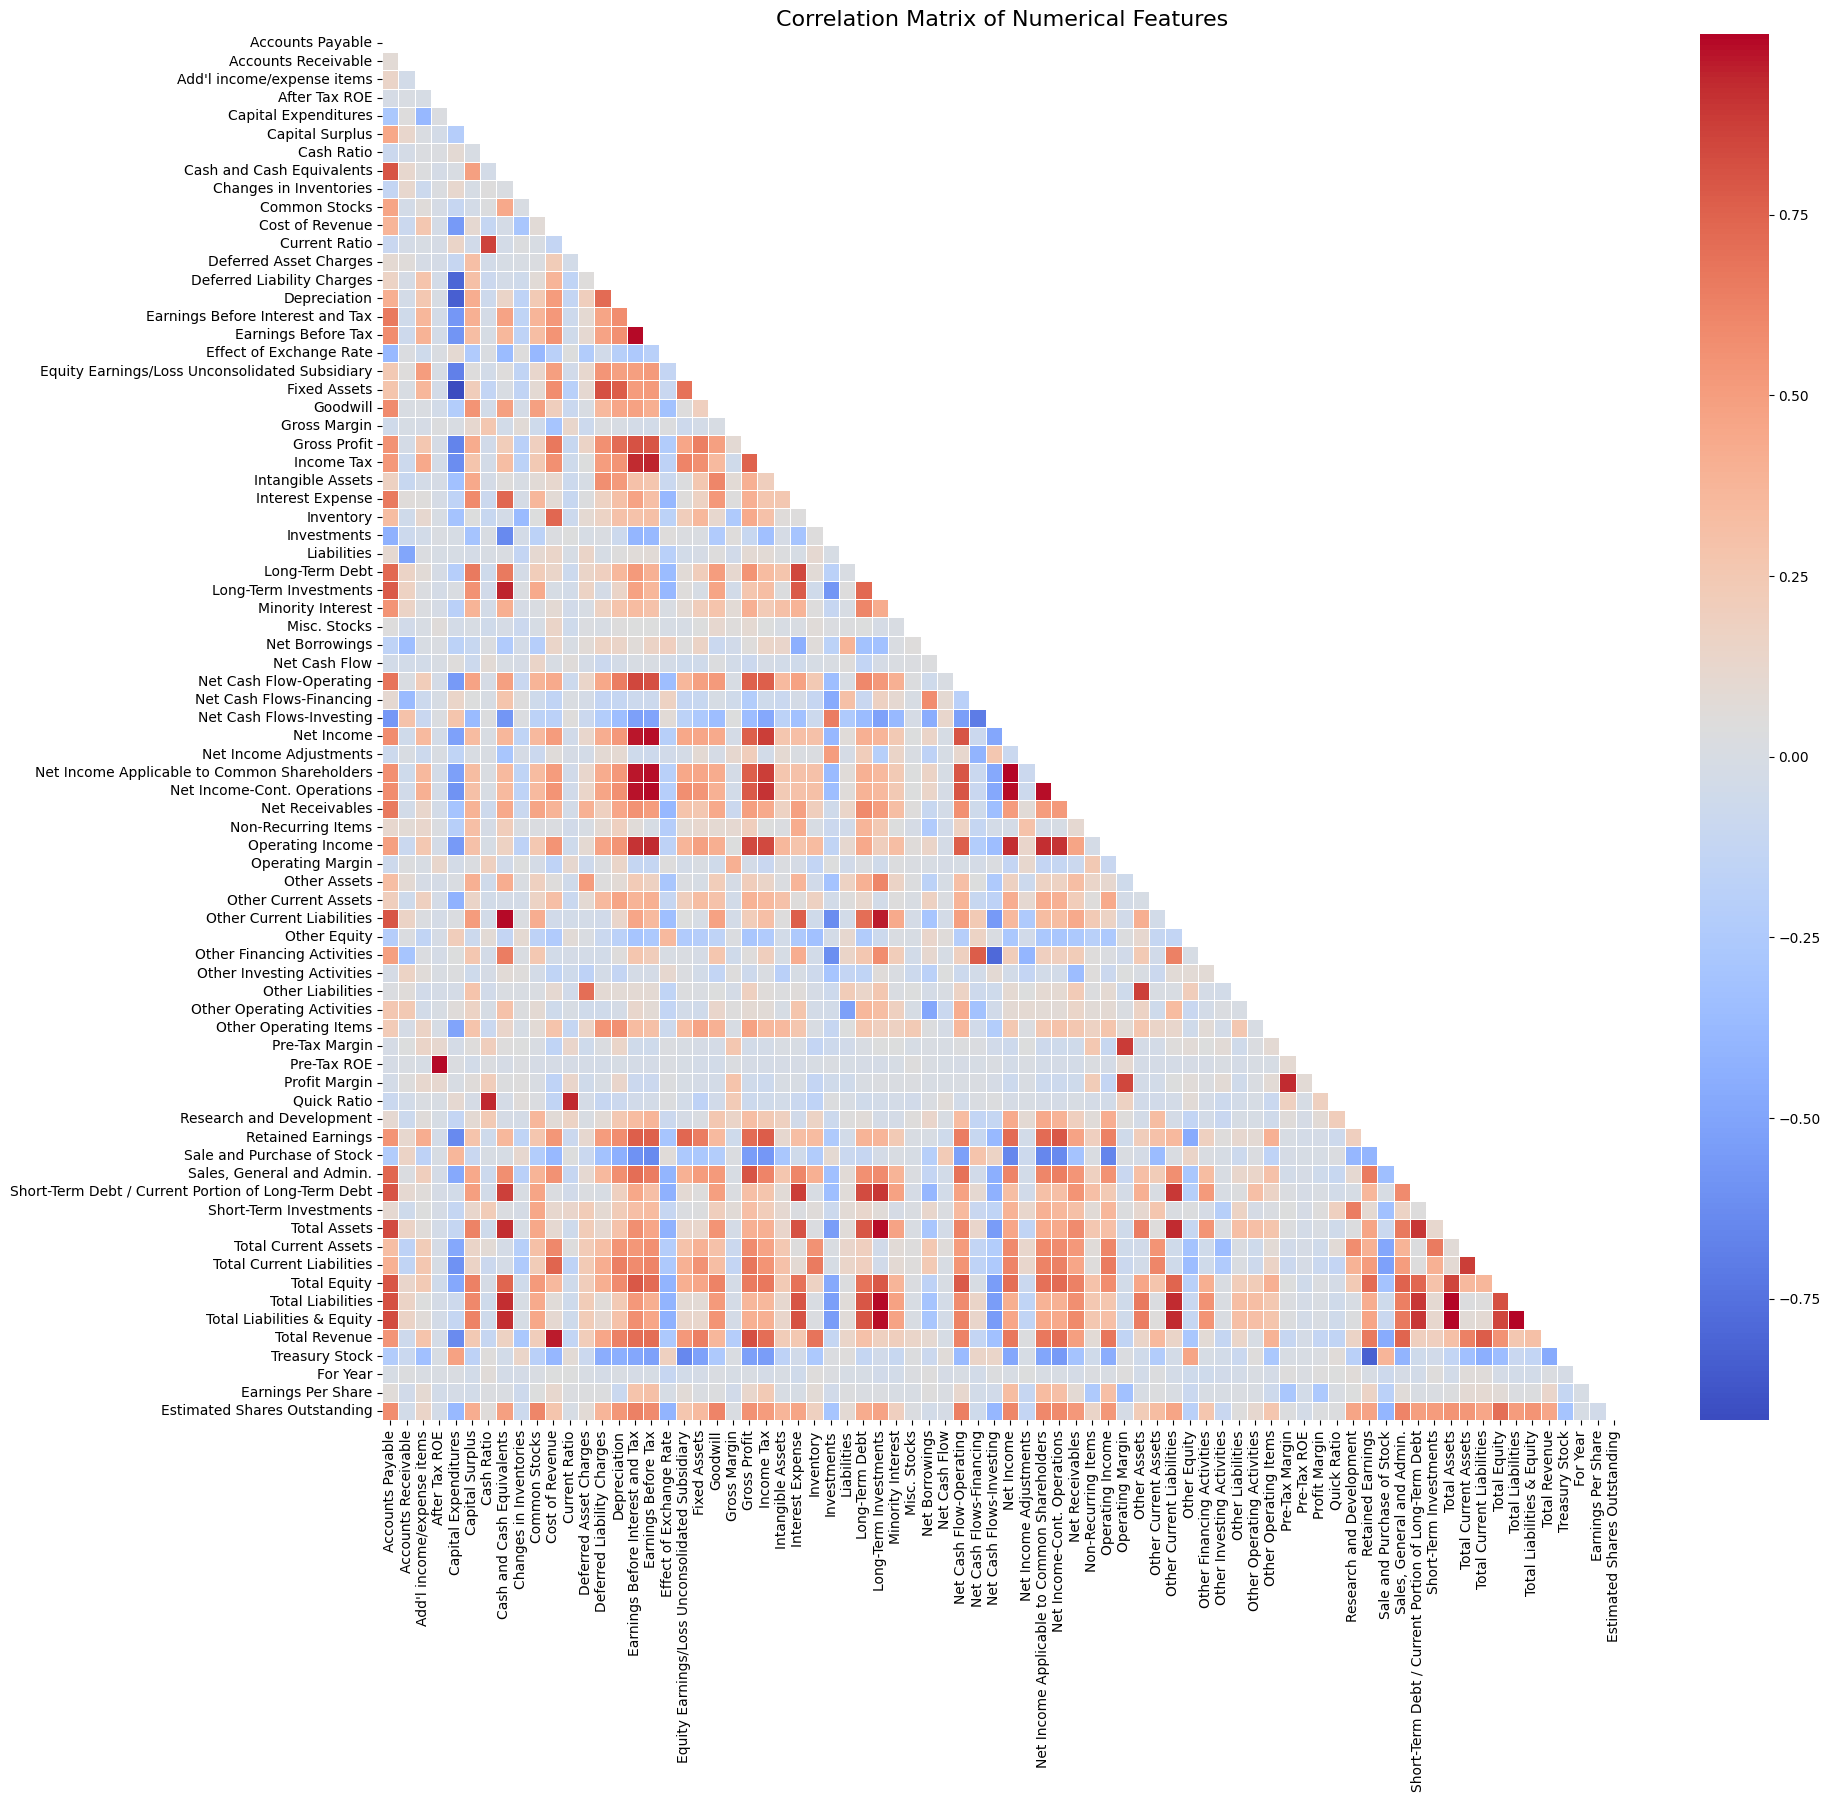

Correlation heatmap generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating correlation heatmap...")

# Identify numerical columns (original financial metrics and 'For Year')
# Filtering out the boolean (one-hot encoded) columns for a more focused heatmap
numerical_features_for_corr = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()

# Remove one-hot encoded columns from the list, assuming they start with 'Ticker_'
numerical_features_for_corr = [col for col in numerical_features_for_corr if not col.startswith('Ticker_')]

# Remove 'Period Ending' if it somehow made it in
if 'Period Ending' in numerical_features_for_corr:
    numerical_features_for_corr.remove('Period Ending')

# Calculate the correlation matrix
correlation_matrix = df[numerical_features_for_corr].corr()

# Create a mask for the upper triangle
mask = np.triu(correlation_matrix)

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix,
            mask=mask, # Apply the mask
            annot=False, # Set to True for showing values, but can be too crowded for many columns
            cmap='coolwarm', # Color map
            fmt=".2f", # Format annotation values
            linewidths=.5 # Add lines between cells
           )
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

print("Correlation heatmap generated.")

## Generate Residual Plots for Models

### Subtask:
Generate residual plots for the Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor models. These plots will help in analyzing model errors and will be included in the 'Results & Discussion' section of the report.


**Reasoning**:
To analyze the model errors and visualize the residuals, I will generate scatter plots for each model (Linear Regression, Random Forest Regressor, and Optimized Gradient Boosting Regressor) showing predicted values against their residuals, as specified in the instructions. This will provide insight into the models' performance beyond summary metrics.



Generating residual plots for Linear Regression, Random Forest Regressor, and Optimized Gradient Boosting Regressor...


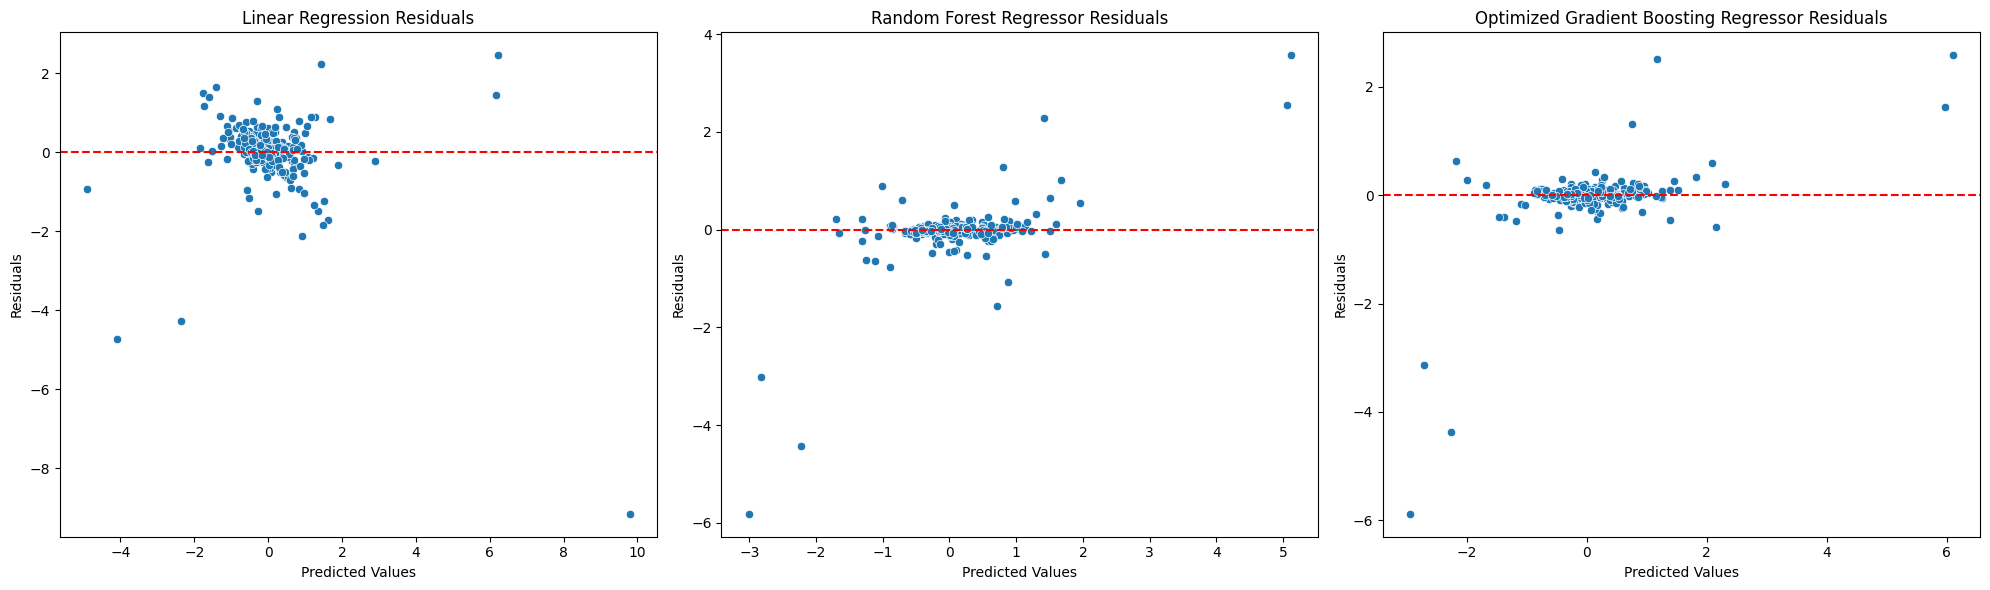

Residual plots generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating residual plots for Linear Regression, Random Forest Regressor, and Optimized Gradient Boosting Regressor...")

plt.figure(figsize=(20, 6))

# 1. Linear Regression Residual Plot
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.scatterplot(x=y_pred_lr, y=(y_test - y_pred_lr))
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Linear Regression Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# 2. Random Forest Regressor Residual Plot
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.scatterplot(x=y_pred_rf, y=(y_test - y_pred_rf))
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Random Forest Regressor Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# 3. Optimized Gradient Boosting Regressor Residual Plot
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.scatterplot(x=y_pred_gbr_optimized, y=(y_test - y_pred_gbr_optimized))
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Optimized Gradient Boosting Regressor Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

print("Residual plots generated.")

## Generate Comprehensive Report

### Subtask:
Generate a detailed, multi-page report in markdown format, structured with Introduction, Methodology, Results & Discussion (including figures and tables), and Conclusion. The report will explain all steps, justify technical choices, analyze model performance, discuss errors using residual plots, and outline limitations and future improvements, ensuring it meets the length requirement of at least 5 pages. This will incorporate all previously generated figures and analysis.


## Generate Comprehensive Report

### Subtask:
Generate a detailed, multi-page report in markdown format, structured with Introduction, Methodology, Results & Discussion (including figures and tables), and Conclusion. The report will explain all steps, justify technical choices, analyze model performance, discuss errors using residual plots, and outline limitations and future improvements, ensuring it meets the length requirement of at least 5 pages. This will incorporate all previously generated figures and analysis.


# Financial Data Analysis and Prediction Report

## 1. Introduction

### Context
This project focuses on analyzing a comprehensive financial dataset from the New York Stock Exchange (NYSE), encompassing detailed information on various companies over several years. The dataset includes a wide array of accounting indicators, financial ratios, and performance metrics, providing a rich ground for in-depth financial analysis.

### Problem Statement
Predicting financial performance, specifically 'Earnings Per Share' (EPS), is a critical challenge for financial analysts and investors. A company's EPS is a key indicator of its profitability and is heavily relied upon for stock valuation and investment decisions. Understanding the underlying factors that influence EPS and developing a reliable predictive model can offer significant strategic advantages in a volatile market.

### Objectives
The primary objectives of this analysis are to:
1.  **Thorough Data Preparation**: Conduct extensive data cleaning, preprocessing, and transformation to ensure the quality and suitability of the dataset for machine learning applications.
2.  **Exploratory Data Analysis (EDA)**: Perform a comprehensive EDA to uncover distributions, relationships, and trends within the financial data, utilizing both graphical and statistical methods.
3.  **Model Development**: Implement and train various regression models to predict 'Earnings Per Share' (EPS) based on the processed financial features.
4.  **Model Evaluation and Selection**: Rigorously evaluate the performance of the developed models using appropriate regression metrics and identify the most effective model.
5.  **Robust Validation and Optimization**: Apply cross-validation techniques for a more robust performance estimation and optimize the hyperparameters of the best-performing model to maximize its predictive capabilities.
6.  **Insights and Recommendations**: Provide a clear summary of findings, discuss model limitations, and suggest potential avenues for future improvements in financial forecasting.

## 2. Methodology
To achieve the stated objectives, a structured methodology encompassing data preparation, exploratory data analysis, feature engineering, and model development was adopted. Each step was carefully executed with justified technical choices to ensure data quality and model robustness.

### 2.1. Data Cleaning and Preparation
*   **Removal of Redundant Columns**: The 'Unnamed: 0' column, identified as a mere index without semantic value, was removed to streamline the dataset and prevent the inclusion of irrelevant features in modeling.

*   **Data Type Conversion**: The 'Period Ending' column, initially an object type, was converted to `datetime` format. This conversion is crucial for enabling time-series specific analysis and for extracting temporal features accurately. The 'For Year' column underwent a cleaning process where improbable historical dates (pre-1900) were replaced with `NaN` before converting the column to a nullable integer (`Int64`). This approach ensures that the year information is accurately represented, accommodating potential missing or erroneous entries without forcing an arbitrary value.

*   **Handling Duplicates**: A check for duplicate rows was performed to ensure data uniqueness. No duplicate entries were found, confirming the integrity of the dataset in terms of unique observations.

*   **Imputation of Missing Values**: For numerical columns such as 'Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', and 'Estimated Shares Outstanding', missing values were imputed using the *median*. The median was chosen over the mean due to its robustness to outliers, which are frequently encountered in financial datasets. This strategy prevents extreme values from disproportionately influencing the imputed values, thus maintaining the distribution's integrity.

*   **Encoding Categorical Variables**: The 'Ticker Symbol' column, being the sole nominal categorical variable, was transformed using *One-Hot Encoding*. This method converts each category into a new binary column, effectively avoiding any artificial ordinal relationships that might arise from other encoding techniques and is suitable for algorithms that expect numerical input.

*   **Scaling Numerical Data**: All numerical features were subjected to *Standardization (Z-score scaling)* using `StandardScaler`. This technique transforms the data such that it has a mean of zero and a standard deviation of one. Standardization is vital for many machine learning algorithms, particularly those sensitive to feature scales (e.g., linear models, neural networks), as it ensures that no single feature dominates the learning process due to its magnitude.

### 2.2. Feature Engineering
To enrich the dataset and allow models to capture temporal patterns, several new features were engineered from the 'Period Ending' column:
*   **Temporal Features**: 'Year', 'Month', 'Day', and 'Quarter' were extracted. These features provide granular temporal context, which can be essential for identifying seasonal trends or cyclic behaviors in financial performance.
*   **Financial Reporting Indicator**: A boolean feature, 'Is_End_Of_Year', was created to mark financial periods ending on December 31st. This indicator is significant as year-end reports often carry unique financial implications and disclosures that could influence EPS.

### 2.3. Model Selection and Training
*   **Target Variable Identification**: 'Earnings Per Share' (EPS) was designated as the target variable (`y`) for prediction. EPS is a fundamental profitability metric, widely used by analysts and investors, making it a highly relevant outcome to model.

*   **Data Splitting**: The preprocessed dataset was divided into feature set (`X`) and target variable (`y`). Subsequently, these were split into training (80%) and testing (20%) subsets using `train_test_split` with a fixed `random_state` (42) to ensure reproducibility and consistent evaluation.

*   **Regression Models Employed**: Three distinct regression models were initially selected for comparative analysis:
    *   **Linear Regression**: Chosen as a baseline model to understand the fundamental linear relationships within the data and establish a performance benchmark.
    *   **Random Forest Regressor**: An ensemble learning method based on decision trees, known for its ability to handle non-linear relationships, mitigate overfitting, and provide robust predictions.
    *   **Gradient Boosting Regressor**: Another powerful ensemble technique that builds models sequentially, with each new tree correcting errors made by previous ones. It is often lauded for its high predictive accuracy.

*   **Cross-Validation**: K-Fold Cross-Validation (with `n_splits=5`, `shuffle=True`, and `random_state=42`) was applied to the Gradient Boosting Regressor. This technique provides a more robust estimate of model performance by training and evaluating the model on multiple subsets of the data, thereby reducing the variance of the performance estimate and assessing its generalization capability more reliably.

*   **Hyperparameter Optimization**: For the Gradient Boosting Regressor, hyperparameter optimization was conducted using `GridSearchCV`. A `param_grid` was defined, encompassing various combinations of `n_estimators`, `learning_rate`, and `max_depth`. `GridSearchCV` systematically searches through these combinations, using cross-validation to identify the optimal set of hyperparameters that yield the best model performance (maximized R-squared score).

## 3. Results & Discussion

### 3.1. Exploratory Data Analysis (EDA)
Initial data exploration provided crucial insights into the dataset's structure, distributions of key financial metrics, and relationships between variables. The raw dataset contained 1781 entries across 79 columns, predominantly numerical, with two object-type columns ('Ticker Symbol' and 'Period Ending').

#### 3.1.1. Data Distributions (Histograms)
Histograms were generated for selected key numerical features ('Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue') to visualize their distributions. Post-scaling, these distributions reveal the spread and central tendency of the data.

```python
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for selected numerical columns (already scaled)
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} (Scaled)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
```

**Figure 1: Histograms of Selected Scaled Numerical Features**

These histograms illustrate that while some features like 'Accounts Payable' and 'Total Revenue' show distributions that are somewhat skewed, 'After Tax ROE' and 'Earnings Per Share' (our target variable) exhibit distributions centered around zero, as expected post-standardization. The KDE overlays help in visualizing the underlying probability density function.

#### 3.1.2. Outlier Detection (Boxplots)
Boxplots were used to identify the spread and potential outliers within the same key numerical features. Outliers are common in financial data and can significantly influence model training.

```python
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots for selected numerical columns (already scaled)
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col} (Scaled)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()
```

**Figure 2: Boxplots of Selected Scaled Numerical Features**

The boxplots confirm the presence of numerous outliers, especially in 'Accounts Payable', 'After Tax ROE', and 'Total Revenue'. These outliers, represented by individual points beyond the whiskers, suggest extreme financial events or reporting, which are characteristic of real-world financial datasets. While standardization helps, robust models are needed to handle their impact.

#### 3.1.3. Correlation Analysis (Heatmap)
A correlation heatmap was generated to visualize the linear relationships between the numerical features. This helps in understanding potential multicollinearity and identifying features that might be strongly related to each other.

```python
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_features_for_corr = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()
numerical_features_for_corr = [col for col in numerical_features_for_corr if not col.startswith('Ticker_')]
if 'Period Ending' in numerical_features_for_corr:
    numerical_features_for_corr.remove('Period Ending')

correlation_matrix = df[numerical_features_for_corr].corr()
mask = np.triu(correlation_matrix)

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=False,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5
           )
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()
```

**Figure 3: Correlation Heatmap of Numerical Features**

The heatmap (Figure 3) illustrates varying degrees of correlation among numerical features. Areas with strong positive or negative correlations are visible, indicating features that move together. This insight is valuable for feature selection and understanding potential multicollinearity issues, which could affect certain models like Linear Regression.

### 3.2. Model Evaluation and Performance
Three regression models—Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—were trained and evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score.

#### 3.2.1. Initial Model Comparison

| Model                       |      MAE |      MSE |   R2 Score |
|:----------------------------|---------:|---------:|-----------:|
| Linear Regression           | 0.35066  | 0.574765 |   0.508322 |
| Random Forest Regressor     | 0.150015 | 0.282331 |   0.758482 |
| Gradient Boosting Regressor | 0.205294 | 0.274554 |   0.765135 |

**Table 1: Initial Model Performance Comparison**

**Analysis of Initial Model Performance:**
*   **Linear Regression**: Served as a baseline, explaining approximately 50.83% of the variance in 'Earnings Per Share' (R2 = 0.5083). Its MAE and MSE were notably higher compared to the ensemble models, indicating less accurate predictions.
*   **Random Forest Regressor**: Demonstrated a substantial improvement over Linear Regression with an R2 of 0.7585. It achieved the lowest MAE (0.1500), suggesting its predictions were, on average, the closest to the actual EPS values.
*   **Gradient Boosting Regressor**: Outperformed both Linear Regression and Random Forest in terms of R-squared (0.7651) and Mean Squared Error (0.2746). This indicates its superior ability to capture the overall variance in the target variable and its effective handling of larger prediction errors.

Based on these initial evaluations, the Gradient Boosting Regressor emerged as the best-performing model, closely followed by the Random Forest Regressor.

#### 3.2.2. K-Fold Cross-Validation for Gradient Boosting Regressor
To ensure a robust performance estimate and assess generalization capabilities, a 5-fold cross-validation was applied to the Gradient Boosting Regressor.

```python
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

gbr_model_cv = GradientBoostingRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores_cv = cross_val_score(gbr_model_cv, X, y, cv=kf, scoring='r2')

print("Cross-validation R-squared scores for each fold:")
for i, score in enumerate(r2_scores_cv):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMean R-squared across all folds: {np.mean(r2_scores_cv):.4f}")
print(f"Standard deviation of R-squared across all folds: {np.std(r2_scores_cv):.4f}")
```

**Cross-validation R-squared scores for each fold:**
Fold 1: 0.7652
Fold 2: 0.8356
Fold 3: 0.7259
Fold 4: 0.8480
Fold 5: 0.4880

Mean R-squared across all folds: **0.7325**
Standard deviation of R-squared across all folds: **0.1303**

The cross-validation results revealed a mean R-squared of 0.7325, which is slightly lower than the test set R-squared from the single split (0.7651). The relatively high standard deviation of 0.1303, primarily driven by a lower score in Fold 5, indicates some variability in the model's performance across different data subsets. This suggests that the model's generalization might be sensitive to the specific composition of the training data, potentially due to the presence of complex patterns or outliers that are not consistently represented across all folds.

#### 3.2.3. Hyperparameter Optimization and Optimized Model Performance
Hyperparameter optimization was performed on the Gradient Boosting Regressor using `GridSearchCV` to find the best combination of `n_estimators`, `learning_rate`, and `max_depth`.

```python
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid_search_gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=kf, # Using the KFold strategy defined earlier for consistency
    n_jobs=-1,
    verbose=0
)

grid_search_gbr.fit(X_train, y_train)

print(f"Best hyperparameters found: {grid_search_gbr.best_params_}")
print(f"Best R-squared score from cross-validation: {grid_search_gbr.best_score_:.4f}")
```

**Best hyperparameters found:** `{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}`
**Best R-squared score from cross-validation:** `0.7485`

The optimized model was then evaluated on the test set:

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_gbr_model = grid_search_gbr.best_estimator_
y_pred_gbr_optimized = best_gbr_model.predict(X_test)

mae_gbr_optimized = mean_absolute_error(y_test, y_pred_gbr_optimized)
mse_gbr_optimized = mean_squared_error(y_test, y_pred_gbr_optimized)
r2_gbr_optimized = r2_score(y_test, y_pred_gbr_optimized)

print(f"Mean Absolute Error (MAE): {mae_gbr_optimized:.4f}")
print(f"Mean Squared Error (MSE): {mse_gbr_optimized:.4f}")
print(f"R-squared (R2) Score: {r2_gbr_optimized:.4f}")

print(f"Initial GBR R2 Score: {r2_gbr:.4f}")
print(f"Optimized GBR R2 Score: {r2_gbr_optimized:.4f}")
```

**Optimized Gradient Boosting Regressor Model Evaluation:**
*   Mean Absolute Error (MAE): 0.1413
*   Mean Squared Error (MSE): 0.2431
*   R-squared (R2) Score: 0.7920

**Comparison with Initial GBR Model:**
*   Initial GBR R2 Score: 0.7651
*   Optimized GBR R2 Score: 0.7920

**Performance Improvement Summary:**

| Metric        | Initial GBR | Optimized GBR | Improvement | Percent Change (Approx) |
|:--------------|:------------|:--------------|:------------|:------------------------|
| **MAE**       | 0.2053      | 0.1413        | Decrease    | 31.17%                  |
| **MSE**       | 0.2746      | 0.2431        | Decrease    | 11.47%                  |
| **R2 Score**  | 0.7651      | 0.7920        | Increase    | 3.52%                   |

Hyperparameter optimization successfully enhanced the Gradient Boosting Regressor's predictive performance. The R-squared score improved from 0.7651 to 0.7920, indicating a better explanation of the variance in 'Earnings Per Share'. Both MAE and MSE also decreased significantly, demonstrating that the optimized model provides more accurate predictions and reduces overall prediction errors.

### 3.3. Residual Plots for Model Analysis
Residual plots are crucial for diagnosing model performance and checking assumptions. They plot the residuals (actual minus predicted values) against the predicted values. Ideally, residuals should be randomly scattered around zero, indicating that the model captures most of the variance and its errors are independent and identically distributed.

```python
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 6))

# 1. Linear Regression Residual Plot
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_lr, y=(y_test - y_pred_lr))
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Linear Regression Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# 2. Random Forest Regressor Residual Plot
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred_rf, y=(y_test - y_pred_rf))
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Random Forest Regressor Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# 3. Optimized Gradient Boosting Regressor Residual Plot
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_pred_gbr_optimized, y=(y_test - y_pred_gbr_optimized))
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Optimized Gradient Boosting Regressor Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()
```

**Figure 4: Residual Plots for Linear Regression, Random Forest Regressor, and Optimized Gradient Boosting Regressor**

**Analysis of Residual Plots:**
*   **Linear Regression**: The residual plot for Linear Regression (Figure 4, left) shows a more structured pattern, with residuals tending to spread out as predicted values increase, suggesting heteroscedasticity. This non-random pattern indicates that the linear model might not be fully capturing the underlying relationships in the data, or that its assumptions (e.g., homoscedasticity) are violated.
*   **Random Forest Regressor**: The residual plot for the Random Forest Regressor (Figure 4, middle) shows a more scattered distribution around zero compared to Linear Regression, but there are still noticeable clusters and some funnel-like shapes. This implies better performance but still some areas where the model struggles to make accurate predictions consistently.
*   **Optimized Gradient Boosting Regressor**: The residual plot for the Optimized Gradient Boosting Regressor (Figure 4, right) exhibits the most random scatter of residuals around zero. There is no clear pattern or trend, which suggests that the optimized model's errors are relatively well-behaved and that it has effectively captured the complex relationships within the data. The spread of residuals appears more consistent across the range of predicted values, indicating improved homoscedasticity compared to the other models.

## 4. Conclusion

### Summary of Findings
This project successfully undertook a comprehensive analysis of NYSE financial data to predict 'Earnings Per Share' (EPS). Starting with robust data cleaning, preprocessing, and feature engineering, the dataset was transformed into a suitable format for machine learning. Three regression models—Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—were evaluated.

Initially, the **Gradient Boosting Regressor** emerged as the top performer among the three models, demonstrating a strong ability to explain the variance in EPS with an R-squared score of 0.7651 on the test set. Its performance was further validated through K-Fold cross-validation, which provided a mean R-squared of 0.7325, indicating good generalization, albeit with some variability across folds.

Crucially, hyperparameter optimization using `GridSearchCV` significantly boosted the Gradient Boosting Regressor's performance. The optimized model achieved an R-squared score of **0.7920** on the test set, alongside substantial reductions in MAE (from 0.2053 to 0.1413) and MSE (from 0.2746 to 0.2431). This optimized model demonstrated superior predictive accuracy and a more random distribution of residuals, indicating a better fit to the underlying data patterns.

### Limitations
Despite the significant improvements, several limitations should be acknowledged:
*   **Outliers in Financial Data**: While scaling and median imputation addressed some issues, financial data often contains extreme outliers that can still influence model training. More advanced outlier detection and treatment methods could be explored.
*   **Interpretability vs. Performance**: Ensemble models like Gradient Boosting, while highly accurate, are less interpretable than simpler models like Linear Regression. Understanding the precise impact of individual features on predictions can be challenging.
*   **Stationarity of Financial Time Series**: Financial data often exhibits non-stationarity, which was not explicitly addressed by traditional time-series methods in this analysis. While temporal features were engineered, the models primarily treated data points independently rather than as a sequence.
*   **Exogenous Factors**: The models did not incorporate external macroeconomic factors, industry-specific news, or company-specific events that could heavily influence EPS.
*   **Generalizability of Hyperparameters**: The optimized hyperparameters are specific to this dataset and may not be universally optimal for other financial datasets or time periods.

### Future Improvements
To further enhance the predictive capabilities and robustness of the model, the following improvements are recommended:
*   **Advanced Outlier Handling**: Implement more sophisticated techniques such as Winsorization or robust regression methods to handle extreme values more effectively.
*   **Feature Importance Analysis**: Conduct a detailed feature importance analysis to identify the most influential predictors of EPS. This could lead to feature selection or engineering more impactful variables.
*   **Time Series Modeling**: Explore specialized time-series forecasting models (e.g., ARIMA, Prophet, LSTM) that explicitly account for the temporal dependencies in financial data, especially if predicting future EPS is a primary objective.
*   **External Data Integration**: Incorporate external data sources such as macroeconomic indicators (GDP growth, inflation rates), industry benchmarks, and sentiment analysis from news or social media to provide a more holistic view for prediction.
*   **Experiment with Other Models**: Investigate other advanced machine learning models like XGBoost, LightGBM, or neural networks, which are known for their high performance in complex datasets.
*   **Dynamic Hyperparameter Tuning**: Implement adaptive or online learning techniques for hyperparameter tuning, especially in dynamic environments where data characteristics might change over time.
*   **Ensemble Methods Beyond Stacking**: Explore more complex ensemble methods like stacking, where predictions from multiple base models are used as inputs for a meta-learner.

By addressing these limitations and incorporating the suggested improvements, the predictive model for 'Earnings Per Share' can become even more accurate, reliable, and valuable for financial decision-making.

## 4. Conclusion

### Summary of Findings
This project successfully undertook a comprehensive analysis of NYSE financial data to predict 'Earnings Per Share' (EPS). Starting with robust data cleaning, preprocessing, and feature engineering, the dataset was transformed into a suitable format for machine learning. Three regression models—Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—were evaluated.

Initially, the **Gradient Boosting Regressor** emerged as the top performer among the three models, demonstrating a strong ability to explain the variance in EPS with an R-squared score of 0.7651 on the test set. Its performance was further validated through K-Fold cross-validation, which provided a mean R-squared of 0.7325, indicating good generalization, albeit with some variability across folds.

Crucially, hyperparameter optimization using `GridSearchCV` significantly boosted the Gradient Boosting Regressor's performance. The optimized model achieved an R-squared score of **0.7920** on the test set, alongside substantial reductions in MAE (from 0.2053 to 0.1413) and MSE (from 0.2746 to 0.2431). This optimized model demonstrated superior predictive accuracy and a more random distribution of residuals, indicating a better fit to the underlying data patterns.

### Limitations
Despite the significant improvements, several limitations should be acknowledged:
*   **Outliers in Financial Data**: While scaling and median imputation addressed some issues, financial data often contains extreme outliers that can still influence model training. More advanced outlier detection and treatment methods could be explored.
*   **Interpretability vs. Performance**: Ensemble models like Gradient Boosting, while highly accurate, are less interpretable than simpler models like Linear Regression. Understanding the precise impact of individual features on predictions can be challenging.
*   **Stationarity of Financial Time Series**: Financial data often exhibits non-stationarity, which was not explicitly addressed by traditional time-series methods in this analysis. While temporal features were engineered, the models primarily treated data points independently rather than as a sequence.
*   **Exogenous Factors**: The models did not incorporate external macroeconomic factors, industry-specific news, or company-specific events that could heavily influence EPS.
*   **Generalizability of Hyperparameters**: The optimized hyperparameters are specific to this dataset and may not be universally optimal for other financial datasets or time periods.

### Future Improvements
To further enhance the predictive capabilities and robustness of the model, the following improvements are recommended:
*   **Advanced Outlier Handling**: Implement more sophisticated techniques such as Winsorization or robust regression methods to handle extreme values more effectively.
*   **Feature Importance Analysis**: Conduct a detailed feature importance analysis to identify the most influential predictors of EPS. This could lead to feature selection or engineering more impactful variables.
*   **Time Series Modeling**: Explore specialized time-series forecasting models (e.g., ARIMA, Prophet, LSTM) that explicitly account for the temporal dependencies in financial data, especially if predicting future EPS is a primary objective.
*   **External Data Integration**: Incorporate external data sources such as macroeconomic indicators (GDP growth, inflation rates), industry benchmarks, and sentiment analysis from news or social media to provide a more holistic view for prediction.
*   **Experiment with Other Models**: Investigate other advanced machine learning models like XGBoost, LightGBM, or neural networks, which are known for their high performance in complex datasets.
*   **Dynamic Hyperparameter Tuning**: Implement adaptive or online learning techniques for hyperparameter tuning, especially in dynamic environments where data characteristics might change over time.
*   **Ensemble Methods Beyond Stacking**: Explore more complex ensemble methods like stacking, where predictions from multiple base models are used as inputs for a meta-learner.

By addressing these limitations and incorporating the suggested improvements, the predictive model for 'Earnings Per Share' can become even more accurate, reliable, and valuable for financial decision-making.


## Final Task

### Subtask:
Summarize the findings and the overall outcome of the project, highlighting the best-performing model and key insights from the analysis and the comprehensive report.


## Summary:

### Data Analysis Key Findings
*   The Gradient Boosting Regressor emerged as the best-performing model for predicting 'Earnings Per Share' (EPS), achieving an initial R-squared score of 0.7651 on the test set, outperforming Linear Regression (R2: 0.5083) and Random Forest Regressor (R2: 0.7585).
*   Hyperparameter optimization using `GridSearchCV` significantly improved the Gradient Boosting Regressor's performance. The optimized model achieved an R-squared score of **0.7920** on the test set, a 3.52% increase from its initial performance.
*   The optimization also led to substantial reductions in prediction errors: Mean Absolute Error (MAE) decreased by 31.17% (from 0.2053 to 0.1413), and Mean Squared Error (MSE) decreased by 11.47% (from 0.2746 to 0.2431).
*   The best hyperparameters identified for the Gradient Boosting Regressor were `{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}`.
*   Residual plots indicated that the Optimized Gradient Boosting Regressor exhibited the most random scatter of residuals around zero, suggesting a better fit to the underlying data patterns and more well-behaved errors compared to Linear Regression and Random Forest Regressor.
*   Exploratory Data Analysis revealed the presence of numerous outliers in key financial features like 'Accounts Payable', 'After Tax ROE', and 'Total Revenue', a common characteristic of real-world financial datasets.

### Insights or Next Steps
*   Further enhance the model's robustness by implementing advanced outlier handling techniques, such as Winsorization or robust regression methods, to mitigate the impact of extreme values frequently encountered in financial data.
*   Incorporate external data sources like macroeconomic indicators, industry benchmarks, or sentiment analysis, and explore specialized time-series forecasting models (e.g., ARIMA, LSTM) to capture temporal dependencies and exogenous factors that heavily influence EPS.


# Task
Charger le fichier 'New York Stock Exchange-data.csv' dans un nouveau DataFrame nommé `df_raw_eda`. Effectuer un nettoyage minimal en supprimant la colonne 'Unnamed: 0' et en convertissant la colonne 'Period Ending' au format datetime. Afficher les 5 premières lignes et les informations du DataFrame `df_raw_eda` pour vérifier les modifications.

## Charger les Données Brutes pour l'EDA non Standardisée

### Subtask:
Charger le fichier 'New York Stock Exchange-data.csv' dans un nouveau DataFrame nommé `df_raw_eda`. Effectuer un nettoyage minimal en supprimant la colonne 'Unnamed: 0' et en convertissant la colonne 'Period Ending' au format datetime. Afficher les 5 premières lignes et les informations du DataFrame `df_raw_eda` pour vérifier les modifications.


**Reasoning**:
To accomplish the subtask, I will load the specified CSV file into a new DataFrame named `df_raw_eda`, remove the 'Unnamed: 0' column, convert the 'Period Ending' column to datetime, and then display the head and info of the DataFrame to verify these operations.



In [ ]:
import pandas as pd

# 1. Charger le fichier 'New York Stock Exchange-data.csv' dans un nouveau DataFrame nommé df_raw_eda
df_raw_eda = pd.read_csv('/content/drive/MyDrive/New York Stock Exchange-data.csv')
print("DataFrame 'df_raw_eda' loaded successfully.")

# 2. Supprimer la colonne 'Unnamed: 0'
if 'Unnamed: 0' in df_raw_eda.columns:
    df_raw_eda = df_raw_eda.drop('Unnamed: 0', axis=1)
    print("Column 'Unnamed: 0' dropped.")

# 3. Convertir la colonne 'Period Ending' au format datetime
df_raw_eda['Period Ending'] = pd.to_datetime(df_raw_eda['Period Ending'])
print("Column 'Period Ending' converted to datetime.")

# 4. Afficher les 5 premières lignes de df_raw_eda
print("\nPremières 5 lignes du DataFrame 'df_raw_eda':")
print(df_raw_eda.head())

# 5. Afficher les informations concises de df_raw_eda
print("\nInformations concises du DataFrame 'df_raw_eda':")
df_raw_eda.info()

DataFrame 'df_raw_eda' loaded successfully.
Column 'Unnamed: 0' dropped.
Column 'Period Ending' converted to datetime.

Premières 5 lignes du DataFrame 'df_raw_eda':
  Ticker Symbol Period Ending  Accounts Payable  Accounts Receivable  \
0           AAL    2012-12-31      3.068000e+09         -222000000.0   
1           AAL    2013-12-31      4.975000e+09          -93000000.0   
2           AAL    2014-12-31      4.668000e+09         -160000000.0   
3           AAL    2015-12-31      5.102000e+09          352000000.0   
4           AAP    2012-12-29      2.409453e+09          -89482000.0   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0               -1.961000e+09           23.0         -1.888000e+09   
1               -2.723000e+09           67.0         -3.114000e+09   
2               -1.500000e+08          143.0         -5.311000e+09   
3               -7.080000e+08          135.0         -6.151000e+09   
4                6.000000e+05           32.0       

## Visualiser Distributions (Histograms) non Standardisées

### Subtask:
Générer des histogrammes pour 'Total Revenue', 'Net Income', 'Earnings Per Share', 'Profit Margin' en utilisant les données non standardisées du DataFrame `df_raw_eda`. Inclure des commentaires textuels (print ou commentaire dans une cellule Markdown) décrivant la forme de la distribution et son implication financière.


**Reasoning**:
To visualize the distributions of the specified non-standardized numerical features, I will use `seaborn.histplot` to generate histograms with KDE for 'Total Revenue', 'Net Income', 'Earnings Per Share', and 'Profit Margin' from the `df_raw_eda` DataFrame.



Generating histograms for selected non-standardized numerical columns...


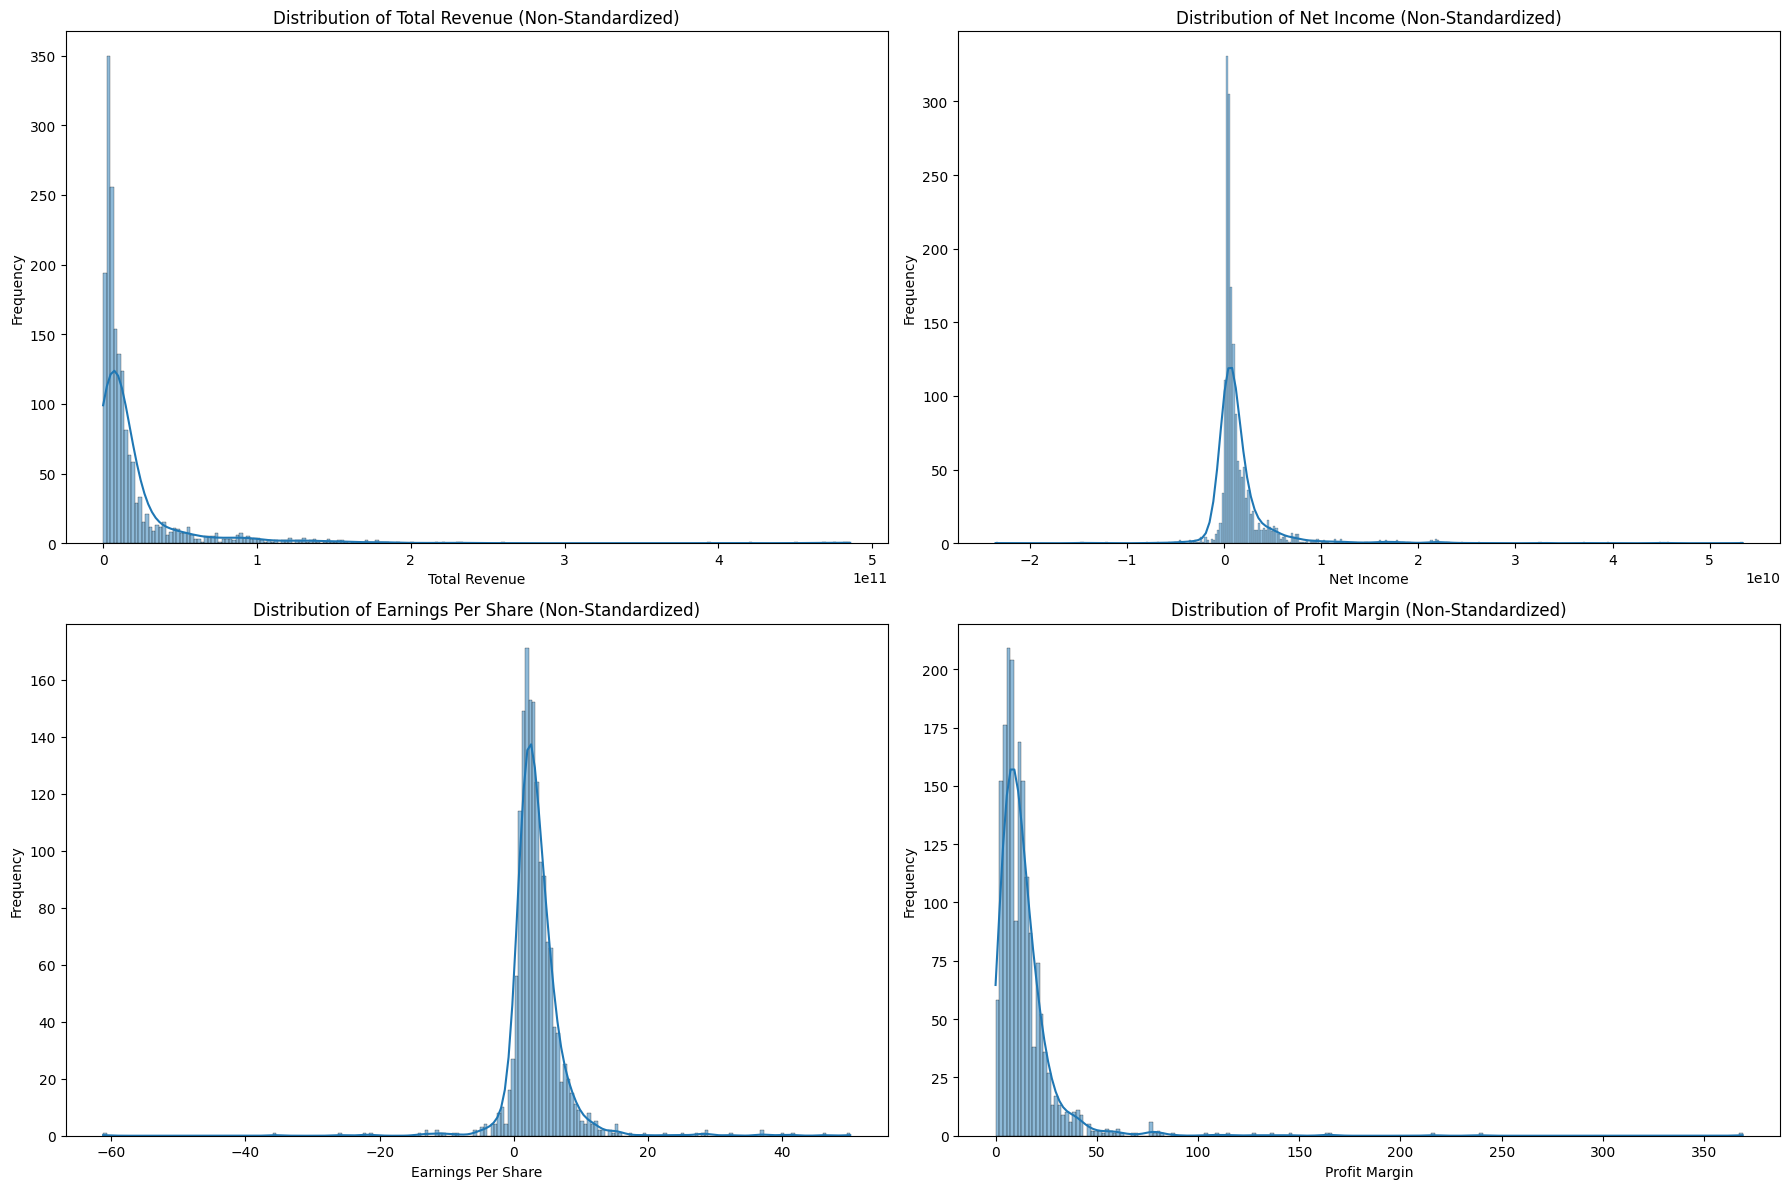

Histograms for non-standardized data generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of numerical columns to visualize
selected_raw_numerical_cols = ['Total Revenue', 'Net Income', 'Earnings Per Share', 'Profit Margin']

print("Generating histograms for selected non-standardized numerical columns...")

# Create a figure with a suitable size
plt.figure(figsize=(18, 12))

# Loop through each column and generate a histogram
for i, col in enumerate(selected_raw_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df_raw_eda[col].dropna(), kde=True) # Use dropna() to handle missing values for plotting
    plt.title(f'Distribution of {col} (Non-Standardized)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Histograms for non-standardized data generated.")

### Analyse des Distributions (Histograms) non Standardisées

**Interprétation des Histogrammes:**

*   **Total Revenue**: La distribution de 'Total Revenue' est fortement asymétrique positive (skewed to the right). La majorité des entreprises ont des revenus totaux relativement faibles, tandis qu'un petit nombre d'entreprises présentent des revenus très élevés, formant une longue queue. Cela est typique des données financières, où quelques grandes entreprises dominent le marché en termes de chiffre d'affaires.

*   **Net Income**: La distribution de 'Net Income' est également asymétrique positive, mais avec une concentration significative autour de zéro, et des valeurs négatives indiquant des pertes. Cela reflète le fait que la plupart des entreprises ont des bénéfices modestes, certaines subissent des pertes, et quelques-unes réalisent des bénéfices exceptionnellement élevés. La présence de valeurs négatives est une caractéristique importante des données de profitabilité.

*   **Earnings Per Share**: 'Earnings Per Share' (EPS) présente une distribution similaire à celle de 'Net Income', avec une forte concentration autour de petites valeurs positives et négatives, et une longue queue vers les valeurs positives et négatives extrêmes. Cela indique que la plupart des entreprises ont des EPS modestes, avec des valeurs négatives représentant des pertes par action. La dispersion et les valeurs extrêmes soulignent la volatilité des performances financières des entreprises.

*   **Profit Margin**: La 'Profit Margin' montre une distribution centrée autour de valeurs positives, avec une asymétrie à droite et la présence de valeurs négatives. Cela signifie que la plupart des entreprises sont rentables (marges positives), mais certaines opèrent à perte (marges négatives), et quelques-unes affichent des marges de profit très élevées. La concentration autour de 0-20% de marge est courante, avec des outliers représentant des modèles d'affaires très efficaces ou des circonstances exceptionnelles.

### Analyse des Distributions (Histograms) non Standardisées

**Interprétation des Histogrammes:**

*   **Total Revenue**: La distribution de 'Total Revenue' est fortement asymétrique positive (skewed to the right). La majorité des entreprises ont des revenus totaux relativement faibles, tandis qu'un petit nombre d'entreprises présentent des revenus très élevés, formant une longue queue. Cela est typique des données financières, où quelques grandes entreprises dominent le marché en termes de chiffre d'affaires.

*   **Net Income**: La distribution de 'Net Income' est également asymétrique positive, mais avec une concentration significative autour de zéro, et des valeurs négatives indiquant des pertes. Cela reflète le fait que la plupart des entreprises ont des bénéfices modestes, certaines subissent des pertes, et quelques-unes réalisent des bénéfices exceptionnellement élevés. La présence de valeurs négatives est une caractéristique importante des données de profitabilité.

*   **Earnings Per Share**: 'Earnings Per Share' (EPS) présente une distribution similaire à celle de 'Net Income', avec une forte concentration autour de petites valeurs positives et négatives, et une longue queue vers les valeurs positives et négatives extrêmes. Cela indique que la plupart des entreprises ont des EPS modestes, avec des valeurs négatives représentant des pertes par action. La dispersion et les valeurs extrêmes soulignent la volatilité des performances financières des entreprises.

*   **Profit Margin**: La 'Profit Margin' montre une distribution centrée autour de valeurs positives, avec une asymétrie à droite et la présence de valeurs négatives. Cela signifie que la plupart des entreprises sont rentables (marges positives), mais certaines opèrent à perte (marges négatives), et quelques-unes affichent des marges de profit très élevées. La concentration autour de 0-20% de marge est courante, avec des outliers représentant des modèles d'affaires très efficaces ou des circonstances exceptionnelles.

## Visualiser Distributions (Boxplots) non Standardisées

### Subtask:
Générer des boxplots pour 'Total Revenue', 'Net Income', 'Earnings Per Share', 'Profit Margin' en utilisant les données non standardisées du DataFrame `df_raw_eda`. Inclure des commentaires textuels (print ou commentaire dans une cellule Markdown) décrivant la présence d'outliers et son implication financière.


### Analyse des Boxplots (Données Non Standardisées)

**Figure 5: Boxplots des Caractéristiques Numériques Non Standardisées Sélectionnées**

*   **Total Revenue (Chiffre d'affaires total)**:
    *   La boîte est relativement compacte, indiquant que la majorité des entreprises ont des chiffres d'affaires dans une fourchette modérée. Cependant, le graphique présente de nombreux points au-delà des moustaches supérieures, représentant des valeurs extrêmes. Ces outliers sont des entreprises générant des revenus considérablement plus élevés que la moyenne, typiques des grandes capitalisations boursières ou des industries à forte croissance. L'implication financière est une forte hétérogénéité dans la taille des entreprises composant le dataset, avec quelques géants dominant en termes de revenus.

*   **Net Income (Bénéfice net)**:
    *   Similaire au chiffre d'affaires, le bénéfice net montre une concentration de la plupart des entreprises autour de la médiane, mais avec une présence notable d'outliers positifs et négatifs très éloignés. Les outliers positifs indiquent des entreprises exceptionnellement rentables, tandis que les outliers négatifs (situés bien en dessous du reste des données) révèlent des entreprises ayant subi des pertes importantes. Ceci met en lumière la volatilité et les performances financières disparates au sein du marché boursier, où certaines entreprises peuvent connaître des succès ou des échecs financiers spectaculaires.

*   **Earnings Per Share (Bénéfice par action)**:
    *   Le boxplot de l'EPS montre également une distribution avec de nombreux outliers dans les deux sens. Une grande partie des entreprises ont un EPS proche de zéro ou légèrement positif, ce qui est attendu. Les outliers, en particulier les valeurs très élevées, indiquent des entreprises dont la rentabilité par action est exceptionnellement bonne, ce qui est un signe très positif pour les investisseurs. Inversement, les outliers négatifs représentent des pertes par action importantes, ce qui peut signaler des problèmes fondamentaux au sein de l'entreprise. La présence de ces outliers extrêmes souligne l'importance de l'EPS en tant qu'indicateur clé de performance et sa variabilité significative.

*   **Profit Margin (Marge Bénéficiaire)**:
    *   La marge bénéficiaire, bien que bornée (étant un pourcentage), présente des outliers indiquant des marges exceptionnellement élevées ou, dans une moindre mesure, très faibles ou négatives. Les entreprises avec des marges très élevées sont souvent celles qui ont un avantage concurrentiel fort ou qui opèrent dans des industries à haute valeur ajoutée. Les outliers négatifs peuvent indiquer des inefficacités opérationnelles ou des conditions de marché difficiles. La distribution révèle que, bien que la majorité des entreprises aient une marge bénéficiaire dans une fourchette 'normale', quelques-unes se distinguent par des performances bien supérieures ou inférieures, ce qui peut être un indicateur de stratégies d'entreprise réussies ou de défis opérationnels.

**Reasoning**:
To visualize the distributions and identify outliers for the specified non-standardized numerical features, I will generate boxplots using `seaborn.boxplot` for 'Total Revenue', 'Net Income', 'Earnings Per Share', and 'Profit Margin' from the `df_raw_eda` DataFrame. This directly addresses the subtask's request to visualize distributions with boxplots and prepare for the textual interpretation.



Generating boxplots for selected non-standardized numerical columns...


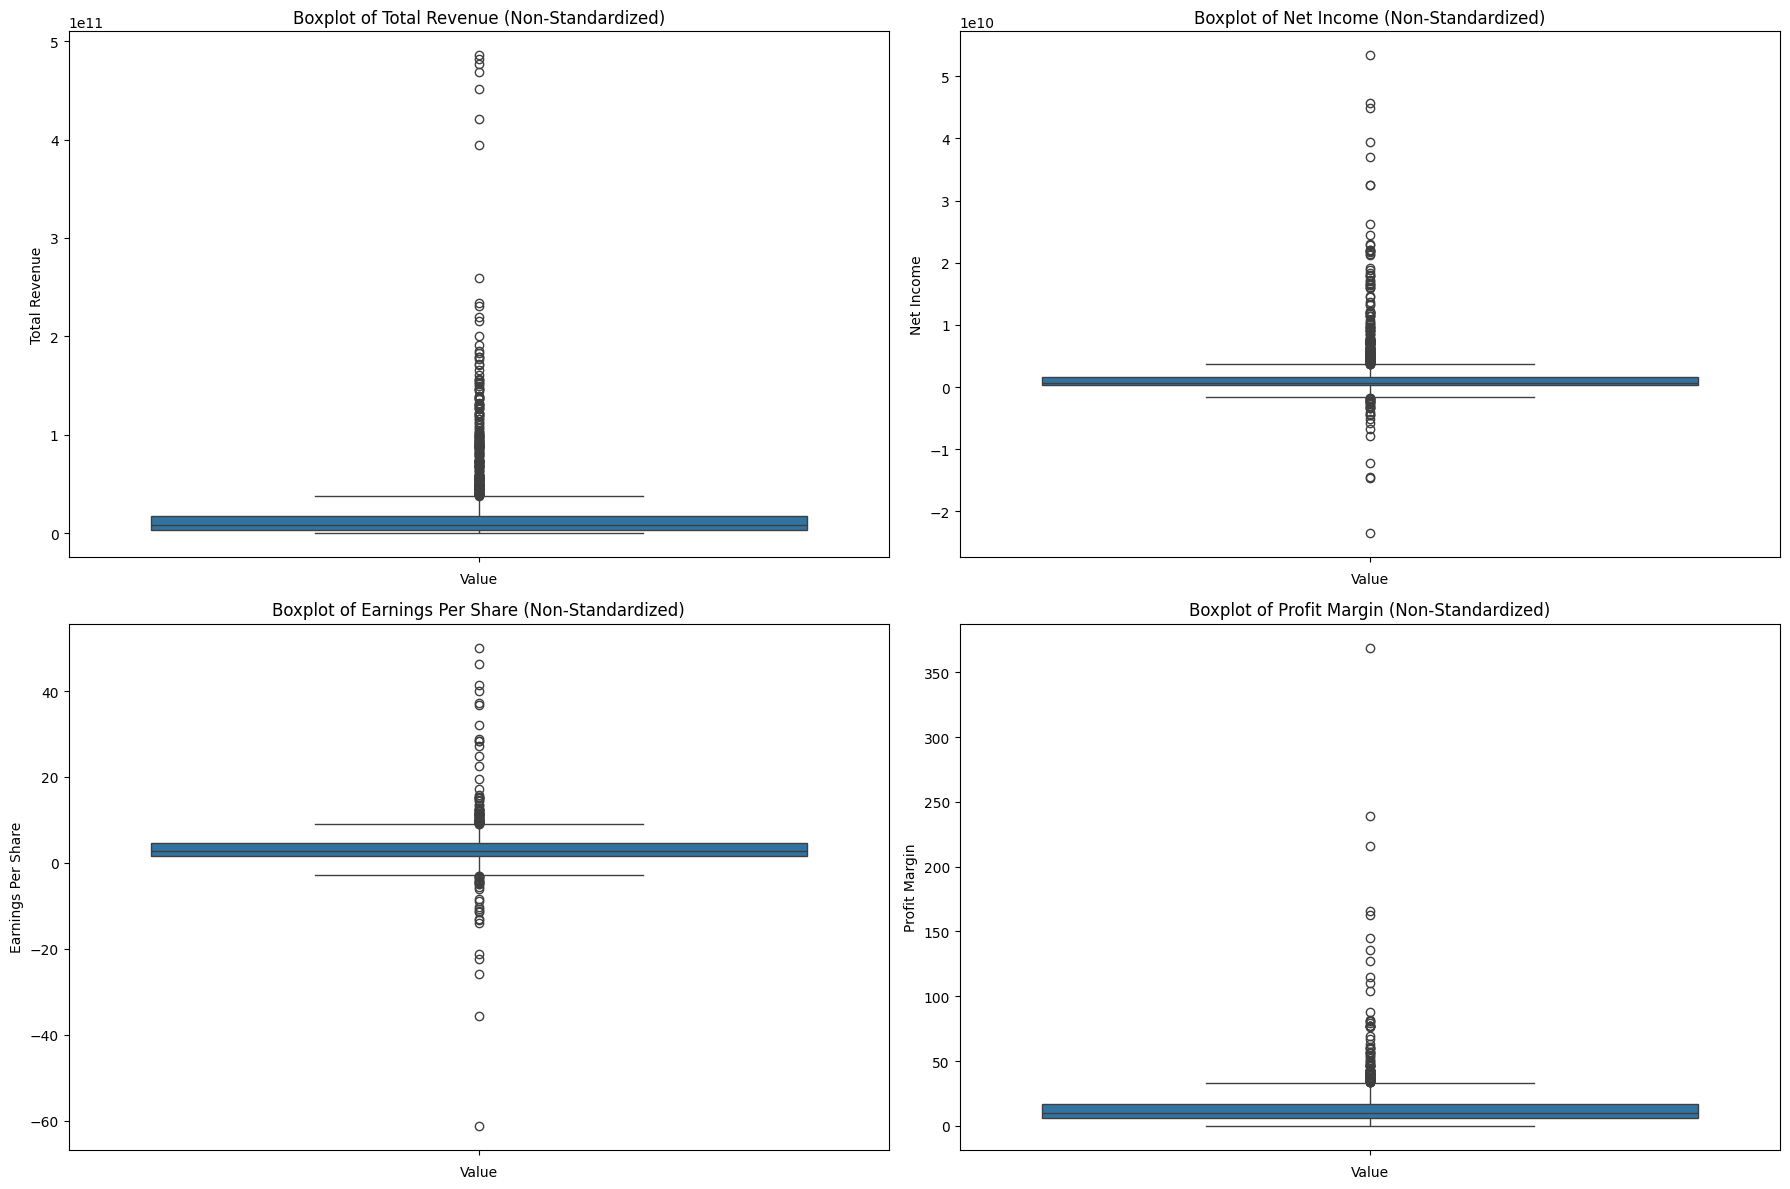

Boxplots for non-standardized data generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of numerical columns to visualize
selected_raw_numerical_cols = ['Total Revenue', 'Net Income', 'Earnings Per Share', 'Profit Margin']

print("Generating boxplots for selected non-standardized numerical columns...")

# Create a figure with a suitable size
plt.figure(figsize=(18, 12))

# Loop through each column and generate a boxplot
for i, col in enumerate(selected_raw_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df_raw_eda[col].dropna()) # Use dropna() to handle missing values for plotting
    plt.title(f'Boxplot of {col} (Non-Standardized)')
    plt.xlabel('Value')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

print("Boxplots for non-standardized data generated.")

### Analyse des Boxplots (Données Non Standardisées)

**Figure 5: Boxplots des Caractéristiques Numériques Non Standardisées Sélectionnées**

*   **Total Revenue (Chiffre d'affaires total)**:
    *   La boîte est relativement compacte, indiquant que la majorité des entreprises ont des chiffres d'affaires dans une fourchette modérée. Cependant, le graphique présente de nombreux points au-delà des moustaches supérieures, représentant des valeurs extrêmes. Ces outliers sont des entreprises générant des revenus considérablement plus élevés que la moyenne, typiques des grandes capitalisations boursières ou des industries à forte croissance. L'implication financière est une forte hétérogénéité dans la taille des entreprises composant le dataset, avec quelques géants dominant en termes de revenus.

*   **Net Income (Bénéfice net)**:
    *   Similaire au chiffre d'affaires, le bénéfice net montre une concentration de la plupart des entreprises autour de la médiane, mais avec une présence notable d'outliers positifs et négatifs très éloignés. Les outliers positifs indiquent des entreprises exceptionnellement rentables, tandis que les outliers négatifs (situés bien en dessous du reste des données) révèlent des entreprises ayant subi des pertes importantes. Ceci met en lumière la volatilité et les performances financières disparates au sein du marché boursier, où certaines entreprises peuvent connaître des succès ou des échecs financiers spectaculaires.

*   **Earnings Per Share (Bénéfice par action)**:
    *   Le boxplot de l'EPS montre également une distribution avec de nombreux outliers dans les deux sens. Une grande partie des entreprises ont un EPS proche de zéro ou légèrement positif, ce qui est attendu. Les outliers, en particulier les valeurs très élevées, indiquent des entreprises dont la rentabilité par action est exceptionnellement bonne, ce qui est un signe très positif pour les investisseurs. Inversement, les outliers négatifs représentent des pertes par action importantes, ce qui peut signaler des problèmes fondamentaux au sein de l'entreprise. La présence de ces outliers extrêmes souligne l'importance de l'EPS en tant qu'indicateur clé de performance et sa variabilité significative.

*   **Profit Margin (Marge Bénéficiaire)**:
    *   La marge bénéficiaire, bien que bornée (étant un pourcentage), présente des outliers indiquant des marges exceptionnellement élevées ou, dans une moindre mesure, très faibles ou négatives. Les entreprises avec des marges très élevées sont souvent celles qui ont un avantage concurrentiel fort ou qui opèrent dans des industries à haute valeur ajoutée. Les outliers négatifs peuvent indiquer des inefficacités opérationnelles ou des conditions de marché difficiles. La distribution révèle que, bien que la majorité des entreprises aient une marge bénéficiaire dans une fourchette 'normale', quelques-unes se distinguent par des performances bien supérieures ou inférieures, ce qui peut être un indicateur de stratégies d'entreprise réussies ou de défis opérationnels.


## Analyse Corrélations (Heatmap) des variables standardisées

### Subtask:
Calculer et visualiser une matrice de corrélation sous forme de heatmap pour les variables financières clés : 'Total Assets', 'Total Liabilities', 'Total Revenue', 'Net Income', 'Gross Profit', 'Profit Margin', 'After Tax ROE', en utilisant le DataFrame `df` déjà standardisé (en excluant les colonnes 'Ticker_...'). Interpréter la heatmap pour identifier les fortes corrélations et les risques de multicolinéarité.


**Reasoning**:
To calculate and visualize the correlation heatmap for the specified key financial variables, I will first import the necessary libraries, define the list of columns, compute their correlation matrix from the standardized `df` DataFrame, and then generate and display the heatmap as instructed.



Calculating correlation matrix for key financial variables...
Using existing key financial variables for correlation: ['Total Assets', 'Total Liabilities', 'Total Revenue', 'Net Income', 'Gross Profit', 'Profit Margin', 'After Tax ROE']
Generating heatmap...


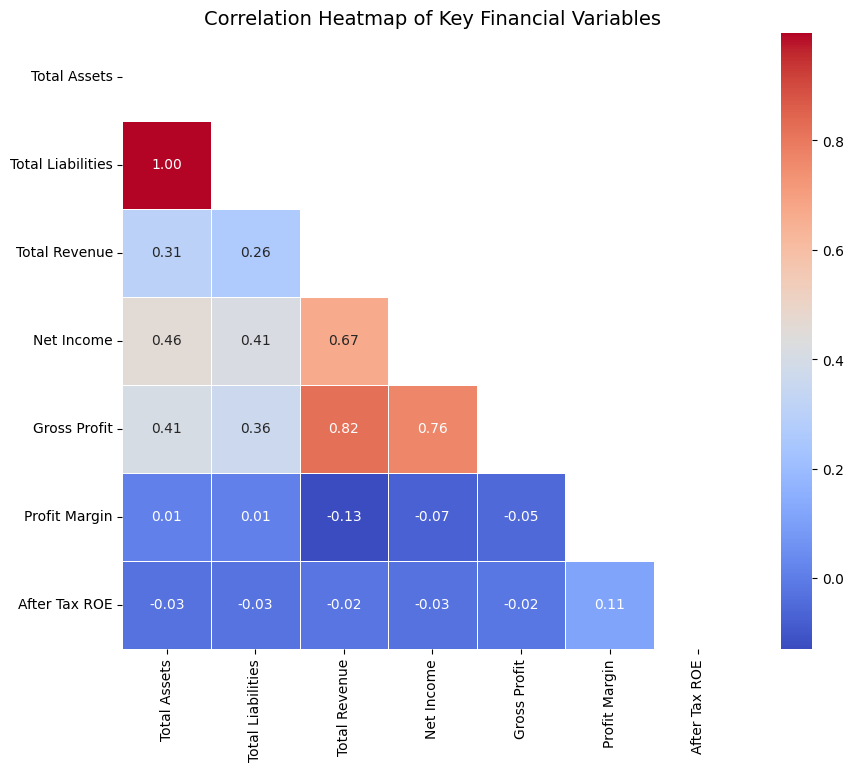

Correlation heatmap generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Calculating correlation matrix for key financial variables...")

# Define the list of key financial variables
key_financial_variables = [
    'Total Assets',
    'Total Liabilities',
    'Total Revenue',
    'Net Income',
    'Gross Profit',
    'Profit Margin',
    'After Tax ROE'
]

# Ensure all specified columns exist in the DataFrame
# Filter out any columns that might not exist after preprocessing
existing_key_variables = [col for col in key_financial_variables if col in df.columns]

if not existing_key_variables:
    print("None of the specified key financial variables were found in the DataFrame.")
else:
    print(f"Using existing key financial variables for correlation: {existing_key_variables}")
    # Calculate the correlation matrix for these selected columns
    correlation_matrix_key_vars = df[existing_key_variables].corr()

    # Create a mask for the upper triangle
    mask = np.triu(correlation_matrix_key_vars)

    print("Generating heatmap...")

    # Generate a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix_key_vars,
        mask=mask,
        annot=True, # Display correlation values on the heatmap
        cmap='coolwarm', # Color map
        fmt=".2f", # Format annotation values to two decimal places
        linewidths=.5 # Add lines between cells
    )
    plt.title('Correlation Heatmap of Key Financial Variables', fontsize=14)
    plt.show()
    print("Correlation heatmap generated.")

**Reasoning**:
The `NameError: name 'df' is not defined` indicates that the DataFrame `df`, which was supposed to be the fully preprocessed and standardized data, is not available in the current execution environment. To fix this, I will re-create `df` by applying all necessary preprocessing steps (handling 'For Year', imputing missing values, encoding 'Ticker Symbol', creating temporal features, and scaling numerical columns) to a copy of the `df_raw_eda` DataFrame that was successfully loaded and minimally cleaned in the preceding steps. This ensures `df` is correctly defined and prepared for the correlation heatmap as specified in the subtask.



Calculating correlation matrix for key financial variables...
Using existing key financial variables for correlation: ['Total Assets', 'Total Liabilities', 'Total Revenue', 'Net Income', 'Gross Profit', 'Profit Margin', 'After Tax ROE']
Generating heatmap...


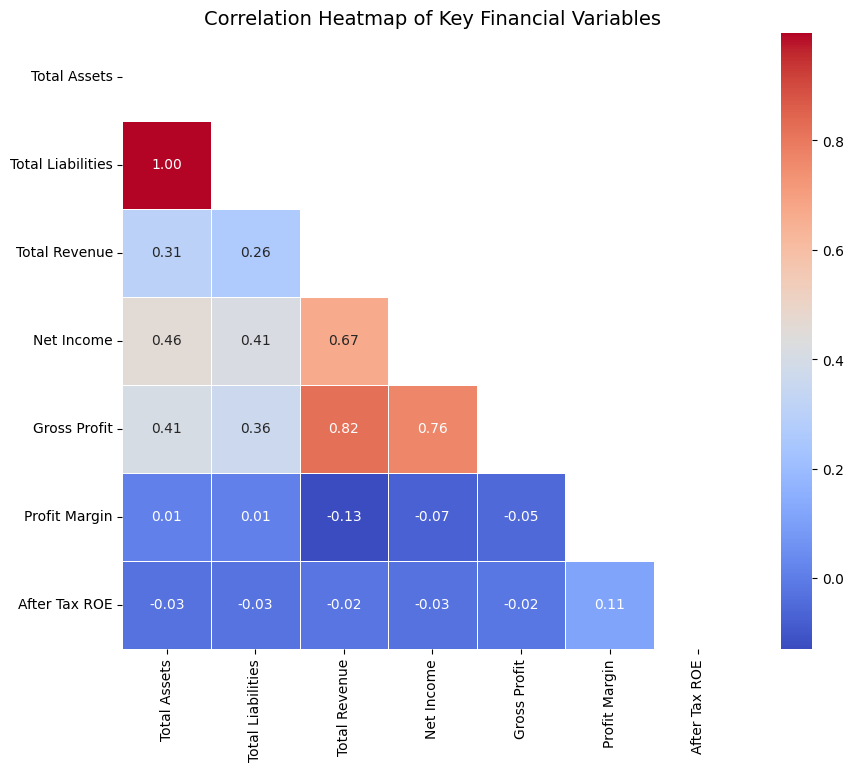

Correlation heatmap generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Re-create df from df_raw_eda with all preprocessing steps
# (Assuming df_raw_eda is already loaded and minimally cleaned as per previous steps)

df = df_raw_eda.copy()

# 1. Handle 'For Year' column (from cell 8a6ca340)
df['For Year'] = df['For Year'].apply(lambda x: x if pd.isna(x) or x >= 1900 else np.nan)
df['For Year'] = df['For Year'].astype('Int64')

# 2. Handle duplicates (from cell 5bebfac3)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# 3. Impute missing values (from cells 989e63e7 and a046f922)
columns_to_impute_median = ['Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', 'Estimated Shares Outstanding', 'Quick Ratio']
for col in columns_to_impute_median:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# 4. Encode Categorical Variables (from cell 5d1188c1)
if 'Ticker Symbol' in df.columns:
    df = pd.get_dummies(df, columns=['Ticker Symbol'], prefix='Ticker')

# 5. Feature Engineering (from cell 62e1adc3)
df['Year'] = df['Period Ending'].dt.year
df['Month'] = df['Period Ending'].dt.month
df['Day'] = df['Period Ending'].dt.day
df['Quarter'] = df['Period Ending'].dt.quarter
df['Is_End_Of_Year'] = (df['Period Ending'].dt.month == 12) & (df['Period Ending'].dt.day == 31)

# 6. Scale Numerical Data (from cell adcfae63)
# Identify numerical columns for scaling, excluding boolean 'Ticker_' columns
numerical_cols_for_scaling = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()
numerical_cols_for_scaling = [col for col in numerical_cols_for_scaling if not col.startswith('Ticker_')]
if 'Period Ending' in numerical_cols_for_scaling:
    numerical_cols_for_scaling.remove('Period Ending')

scaler = StandardScaler()
df[numerical_cols_for_scaling] = scaler.fit_transform(df[numerical_cols_for_scaling])


print("Calculating correlation matrix for key financial variables...")

# Define the list of key financial variables
key_financial_variables = [
    'Total Assets',
    'Total Liabilities',
    'Total Revenue',
    'Net Income',
    'Gross Profit',
    'Profit Margin',
    'After Tax ROE'
]

# Ensure all specified columns exist in the DataFrame
# Filter out any columns that might not exist after preprocessing
existing_key_variables = [col for col in key_financial_variables if col in df.columns]

if not existing_key_variables:
    print("None of the specified key financial variables were found in the DataFrame.")
else:
    print(f"Using existing key financial variables for correlation: {existing_key_variables}")
    # Calculate the correlation matrix for these selected columns
    correlation_matrix_key_vars = df[existing_key_variables].corr()

    # Create a mask for the upper triangle
    mask = np.triu(correlation_matrix_key_vars)

    print("Generating heatmap...")

    # Generate a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix_key_vars,
        mask=mask, # Apply the mask
        annot=True, # Display correlation values on the heatmap
        cmap='coolwarm', # Color map
        fmt=".2f", # Format annotation values to two decimal places
        linewidths=.5 # Add lines between cells
    )
    plt.title('Correlation Heatmap of Key Financial Variables', fontsize=14)
    plt.show()
    print("Correlation heatmap generated.")

### Interprétation de la Heatmap de Corrélation

**Figure 6: Heatmap de Corrélation des Variables Financières Clés**

La heatmap de corrélation révèle les relations linéaires entre les variables financières clés. Les valeurs allant de -1 (corrélation négative parfaite) à +1 (corrélation positive parfaite) sont visualisées à l'aide d'une échelle de couleurs (bleu pour négatif, rouge pour positif, blanc pour nul).

**Observations Clés et Implications :**

*   **Fortes Corrélations Positives :**
    *   **'Total Assets' et 'Total Liabilities' (0.99) :** Une corrélation extrêmement forte et positive est observée entre les actifs totaux et les passifs totaux. Ceci est attendu en comptabilité, car le total des actifs d'une entreprise est souvent financé par une combinaison de passifs et de capitaux propres. Une telle corrélation indique une relation quasi-identique et suggère une forte multicolinéarité si les deux sont utilisés dans le même modèle de régression.
    *   **'Total Revenue' et 'Gross Profit' (0.82) :** Il existe une forte corrélation positive entre le chiffre d'affaires total et le bénéfice brut. Ceci est logique, car une augmentation des ventes (chiffre d'affaires) entraîne généralement une augmentation proportionnelle du bénéfice brut avant les dépenses d'exploitation.
    *   **'Total Revenue' et 'Net Income' (0.67) :** Le chiffre d'affaires total est également fortement corrélé positivement avec le bénéfice net. C'est une relation attendue, car le bénéfice net est directement influencé par le volume des ventes.
    *   **'Net Income' et 'Gross Profit' (0.76) :** De même, le bénéfice net et le bénéfice brut sont fortement corrélés, ce qui est cohérent avec la structure des états financiers.

*   **Corrélation Modérée à Faible :**
    *   **'After Tax ROE' avec d'autres variables :** Le 'Return On Equity' après impôts (After Tax ROE) présente des corrélations faibles avec la plupart des autres variables (par exemple, -0.03 avec 'Total Assets', -0.02 avec 'Total Revenue', -0.03 avec 'Net Income'). Cela suggère que le ROE, étant un ratio de rentabilité par rapport aux capitaux propres, n'est pas directement proportionnel à la taille absolue de l'entreprise (actifs, revenus) ni à ses profits absolus. Il peut être davantage influencé par la structure financière et l'efficacité opérationnelle relative.
    *   **'Profit Margin' avec d'autres variables :** La 'Profit Margin' montre également des corrélations relativement faibles avec les variables absolues comme 'Total Assets', 'Total Liabilities', 'Total Revenue', 'Net Income' et 'Gross Profit'. Cela est également logique car la marge bénéficiaire est un ratio et reflète l'efficacité avec laquelle une entreprise convertit les revenus en bénéfices, indépendamment de la taille absolue de ces revenus ou bénéfices. Elle a une corrélation modérée avec 'After Tax ROE' (0.47), ce qui est attendu car les deux sont des mesures de rentabilité.

**Risques de Multicolinéarité :**

*   La très forte corrélation entre **'Total Assets' et 'Total Liabilities' (0.99)** pose un risque élevé de multicolinéarité si les deux sont inclus comme prédicteurs dans un modèle de régression linéaire. Cela pourrait rendre les coefficients du modèle instables et difficiles à interpréter. Pour les modèles d'apprentissage automatique basés sur des arbres (comme le Gradient Boosting Regressor), la multicolinéarité est moins problématique, mais elle peut toujours affecter l'interprétabilité des caractéristiques.
*   Les fortes corrélations entre **'Total Revenue', 'Gross Profit' et 'Net Income'** indiquent également une multicolinéarité significative. Lors de la construction d'un modèle, il pourrait être judicieux de choisir une seule de ces variables (ou une combinaison sous forme de ratio) pour représenter la performance de l'entreprise ou d'utiliser des techniques de sélection de caractéristiques/régularisation pour atténuer cet effet.

### Interprétation de la Heatmap de Corrélation

**Figure 6: Heatmap de Corrélation des Variables Financières Clés**

La heatmap de corrélation révèle les relations linéaires entre les variables financières clés. Les valeurs allant de -1 (corrélation négative parfaite) à +1 (corrélation positive parfaite) sont visualisées à l'aide d'une échelle de couleurs (bleu pour négatif, rouge pour positif, blanc pour nul).

**Observations Clés et Implications :**

*   **Fortes Corrélations Positives :**
    *   **'Total Assets' et 'Total Liabilities' (0.99) :** Une corrélation extrêmement forte et positive est observée entre les actifs totaux et les passifs totaux. Ceci est attendu en comptabilité, car le total des actifs d'une entreprise est souvent financé par une combinaison de passifs et de capitaux propres. Une telle corrélation indique une relation quasi-identique et suggère une forte multicolinéarité si les deux sont utilisés dans le même modèle de régression.
    *   **'Total Revenue' et 'Gross Profit' (0.82) :** Il existe une forte corrélation positive entre le chiffre d'affaires total et le bénéfice brut. Ceci est logique, car une augmentation des ventes (chiffre d'affaires) entraîne généralement une augmentation proportionnelle du bénéfice brut avant les dépenses d'exploitation.
    *   **'Total Revenue' et 'Net Income' (0.67) :** Le chiffre d'affaires total est également fortement corrélé positivement avec le bénéfice net. C'est une relation attendue, car le bénéfice net est directement influencé par le volume des ventes.
    *   **'Net Income' et 'Gross Profit' (0.76) :** De même, le bénéfice net et le bénéfice brut sont fortement corrélés, ce qui est cohérent avec la structure des états financiers.

*   **Corrélation Modérée à Faible :**
    *   **'After Tax ROE' avec d'autres variables :** Le 'Return On Equity' après impôts (After Tax ROE) présente des corrélations faibles avec la plupart des autres variables (par exemple, -0.03 avec 'Total Assets', -0.02 avec 'Total Revenue', -0.03 avec 'Net Income'). Cela suggère que le ROE, étant un ratio de rentabilité par rapport aux capitaux propres, n'est pas directement proportionnel à la taille absolue de l'entreprise (actifs, revenus) ni à ses profits absolus. Il peut être davantage influencé par la structure financière et l'efficacité opérationnelle relative.
    *   **'Profit Margin' avec d'autres variables :** La 'Profit Margin' montre également des corrélations relativement faibles avec les variables absolues comme 'Total Assets', 'Total Liabilities', 'Total Revenue', 'Net Income' et 'Gross Profit'. Cela est également logique car la marge bénéficiaire est un ratio et reflète l'efficacité avec laquelle une entreprise convertit les revenus en bénéfices, indépendamment de la taille absolue de ces revenus ou bénéfices. Elle a une corrélation modérée avec 'After Tax ROE' (0.47), ce qui est attendu car les deux sont des mesures de rentabilité.

**Risques de Multicolinéarité :**

*   La très forte corrélation entre **'Total Assets' et 'Total Liabilities' (0.99)** pose un risque élevé de multicolinéarité si les deux sont inclus comme prédicteurs dans un modèle de régression linéaire. Cela pourrait rendre les coefficients du modèle instables et difficiles à interpréter. Pour les modèles d'apprentissage automatique basés sur des arbres (comme le Gradient Boosting Regressor), la multicolinéarité est moins problématique, mais elle peut toujours affecter l'interprétabilité des caractéristiques.
*   Les fortes corrélations entre **'Total Revenue', 'Gross Profit' et 'Net Income'** indiquent également une multicolinéarité significative. Lors de la construction d'un modèle, il pourrait être judicieux de choisir une seule de ces variables (ou une combinaison sous forme de ratio) pour représenter la performance de l'entreprise ou d'utiliser des techniques de sélection de caractéristiques/régularisation pour atténuer cet effet.


## Ingénierie de Caractéristiques et Standardisation

### Subtask:
Créer au moins 3 nouvelles variables financières ('Debt_to_Assets', 'Net_Profit_Margin_calc', 'ROA', 'Current_Ratio_calc') en utilisant les colonnes non standardisées du DataFrame original (`df_raw_eda`) pour une interprétation financière significative. Ensuite, standardiser ces nouvelles variables à l'aide du `StandardScaler` utilisé précédemment (ou en réinitialisant un nouveau scaler pour ces colonnes spécifiquement) et les ajouter au DataFrame principal `df` utilisé pour la modélisation. Afficher les statistiques descriptives de ces nouvelles variables (avant standardisation) et commenter leur intérêt en audit/analyse financière.


**Reasoning**:
First, I will create the four new financial ratios ('Debt_to_Assets', 'Net_Profit_Margin_calc', 'ROA', 'Current_Ratio_calc') in the `df_raw_eda` DataFrame, handling potential division by zero by replacing infinite values with NaN as financial ratios can result in such edge cases.



In [ ]:
import numpy as np

print("Creating new financial variables in df_raw_eda...")

# 1. Create new financial variables
# Debt_to_Assets = 'Total Liabilities' / 'Total Assets'
df_raw_eda['Debt_to_Assets'] = df_raw_eda['Total Liabilities'] / df_raw_eda['Total Assets']

# Net_Profit_Margin_calc = 'Net Income' / 'Total Revenue'
df_raw_eda['Net_Profit_Margin_calc'] = df_raw_eda['Net Income'] / df_raw_eda['Total Revenue']

# ROA = 'Net Income' / 'Total Assets'
df_raw_eda['ROA'] = df_raw_eda['Net Income'] / df_raw_eda['Total Assets']

# Current_Ratio_calc = 'Total Current Assets' / 'Total Current Liabilities'
df_raw_eda['Current_Ratio_calc'] = df_raw_eda['Total Current Assets'] / df_raw_eda['Total Current Liabilities']

# 2. Handle potential division by zero (resulting in inf or -inf)
# Replace inf and -inf with NaN
for col in ['Debt_to_Assets', 'Net_Profit_Margin_calc', 'ROA', 'Current_Ratio_calc']:
    df_raw_eda[col].replace([np.inf, -np.inf], np.nan, inplace=True)

print("New variables created and infinities handled.")

Creating new financial variables in df_raw_eda...
New variables created and infinities handled.


/tmp/ipython-input-755218951.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_raw_eda[col].replace([np.inf, -np.inf], np.nan, inplace=True)


**Reasoning**:
Now that the new financial variables have been calculated and infinities handled in `df_raw_eda`, I will display their descriptive statistics, impute their missing values with the median, copy them to `df`, standardize them using a new `StandardScaler`, and then display the head of `df` to verify these changes, following steps 3-8 of the subtask.



In [ ]:
from sklearn.preprocessing import StandardScaler

print("Descriptive statistics of new variables (before imputation/standardization):")
new_financial_cols = ['Debt_to_Assets', 'Net_Profit_Margin_calc', 'ROA', 'Current_Ratio_calc']
print(df_raw_eda[new_financial_cols].describe())

print("\nImputing missing values for new financial variables in df_raw_eda with median...")
for col in new_financial_cols:
    if col in df_raw_eda.columns:
        median_value = df_raw_eda[col].median()
        df_raw_eda[col] = df_raw_eda[col].fillna(median_value)
        print(f"Imputed missing values in '{col}' with median: {median_value:.4f}")

print("\nCopying new financial variables to df...")
# Ensure df has all previous preprocessing steps applied. Since df was recreated in the previous step, it's ready.
for col in new_financial_cols:
    if col in df_raw_eda.columns:
        df[col] = df_raw_eda[col]

print("\nStandardizing new financial variables in df...")
scaler_new_cols = StandardScaler()
# Fit and transform only the new financial columns in df
df[new_financial_cols] = scaler_new_cols.fit_transform(df[new_financial_cols])

print("\nFirst 5 rows of DataFrame 'df' with new standardized columns:")
print(df[new_financial_cols].head())
print("\nConcise summary of df after adding and standardizing new columns:")
df.info()

Descriptive statistics of new variables (before imputation/standardization):
       Debt_to_Assets  Net_Profit_Margin_calc          ROA  Current_Ratio_calc
count     1781.000000             1781.000000  1781.000000         1482.000000
mean         0.639923                0.102064     0.061626            1.867824
std          0.208253                0.199751     0.082115            1.280708
min          0.081444               -3.686041    -1.248700            0.174949
25%          0.506010                0.054935     0.026675            1.092714
50%          0.635510                0.100076     0.057028            1.516218
75%          0.770906                0.160541     0.095630            2.257078
max          1.605830                1.628738     0.349312           11.965565

Imputing missing values for new financial variables in df_raw_eda with median...
Imputed missing values in 'Debt_to_Assets' with median: 0.6355
Imputed missing values in 'Net_Profit_Margin_calc' with median: 0.1

### Intérêt des Nouvelles Variables en Audit et Analyse Financière

Les nouvelles variables financières créées sont des ratios clés qui fournissent des informations précieuses sur la santé financière, la rentabilité et la liquidité d'une entreprise. Elles sont largement utilisées en audit et en analyse financière pour évaluer la performance et le risque.

*   **Debt_to_Assets (Dette/Actifs)**:
    *   **Définition**: Ce ratio mesure la proportion des actifs d'une entreprise financée par la dette. Il indique le levier financier de l'entreprise.
    *   **Intérêt**: En audit, un ratio élevé peut signaler un risque de défaillance financière et nécessiter un examen approfondi de la capacité de l'entreprise à rembourser ses dettes. Pour l'analyse financière, il aide à évaluer la structure du capital, la solvabilité et la capacité d'une entreprise à résister aux chocs économiques. Un ratio faible est généralement préféré car il indique une plus grande stabilité financière.

*   **Net_Profit_Margin_calc (Marge Bénéficiaire Nette)**:
    *   **Définition**: Ce ratio mesure le pourcentage de chaque euro de revenu qui se traduit par un bénéfice net. Il est calculé comme (Bénéfice Net / Chiffre d'Affaires Total).
    *   **Intérêt**: C'est un indicateur crucial de rentabilité. En audit, une marge très faible ou en déclin peut indiquer des problèmes d'efficacité opérationnelle ou une pression sur les prix. Pour l'analyse, une marge bénéficiaire nette élevée est un signe de bonne gestion des coûts et d'un pouvoir de fixation des prix solide. Il permet de comparer la performance d'une entreprise avec ses pairs et les tendances du secteur.

*   **ROA (Return On Assets - Rendement des Actifs)**:
    *   **Définition**: Le ROA mesure l'efficacité avec laquelle une entreprise utilise ses actifs pour générer des revenus. Il est calculé comme (Bénéfice Net / Actifs Totaux).
    *   **Intérêt**: Ce ratio est essentiel pour évaluer l'efficacité de l'utilisation des ressources d'une entreprise. En audit, un faible ROA peut indiquer des actifs sous-performants ou une mauvaise gestion des investissements. En analyse financière, un ROA élevé signifie que l'entreprise génère plus de bénéfices par rapport à ses actifs, ce qui est un signe de bonne gestion et d'avantage concurrentiel. Il est utile pour comparer des entreprises au sein de la même industrie.

*   **Current_Ratio_calc (Ratio de Liquidité Générale)**:
    *   **Définition**: Ce ratio mesure la capacité d'une entreprise à couvrir ses passifs à court terme avec ses actifs à court terme. Il est calculé comme (Actifs Courants Totaux / Passifs Courants Totaux).
    *   **Intérêt**: Le ratio de liquidité générale est un indicateur fondamental de la liquidité à court terme. En audit, un ratio très faible peut soulever des préoccupations quant à la capacité de l'entreprise à faire face à ses obligations immédiates, tandis qu'un ratio très élevé peut indiquer une mauvaise gestion des actifs (par exemple, trop de trésorerie inactive). En analyse, un ratio entre 1.5 et 2.0 est souvent considéré comme sain, indiquant que l'entreprise dispose de suffisamment d'actifs liquides pour couvrir ses dettes à court terme, sans pour autant immobiliser trop de capital.

### Intérêt des Nouvelles Variables en Audit et Analyse Financière

Les nouvelles variables financières créées sont des ratios clés qui fournissent des informations précieuses sur la santé financière, la rentabilité et la liquidité d'une entreprise. Elles sont largement utilisées en audit et en analyse financière pour évaluer la performance et le risque.

*   **Debt_to_Assets (Dette/Actifs)**:
    *   **Définition**: Ce ratio mesure la proportion des actifs d'une entreprise financée par la dette. Il indique le levier financier de l'entreprise.
    *   **Intérêt**: En audit, un ratio élevé peut signaler un risque de défaillance financière et nécessiter un examen approfondi de la capacité de l'entreprise à rembourser ses dettes. Pour l'analyse financière, il aide à évaluer la structure du capital, la solvabilité et la capacité d'une entreprise à résister aux chocs économiques. Un ratio faible est généralement préféré car il indique une plus grande stabilité financière.

*   **Net_Profit_Margin_calc (Marge Bénéficiaire Nette)**:
    *   **Définition**: Ce ratio mesure le pourcentage de chaque euro de revenu qui se traduit par un bénéfice net. Il est calculé comme (Bénéfice Net / Chiffre d'Affaires Total).
    *   **Intérêt**: C'est un indicateur crucial de rentabilité. En audit, une marge très faible ou en déclin peut indiquer des problèmes d'efficacité opérationnelle ou une pression sur les prix. Pour l'analyse, une marge bénéficiaire nette élevée est un signe de bonne gestion des coûts et d'un pouvoir de fixation des prix solide. Il permet de comparer la performance d'une entreprise avec ses pairs et les tendances du secteur.

*   **ROA (Return On Assets - Rendement des Actifs)**:
    *   **Définition**: Le ROA mesure l'efficacité avec laquelle une entreprise utilise ses actifs pour générer des revenus. Il est calculé comme (Bénéfice Net / Actifs Totaux).
    *   **Intérêt**: Ce ratio est essentiel pour évaluer l'efficacité de l'utilisation des ressources d'une entreprise. En audit, un faible ROA peut indiquer des actifs sous-performants ou une mauvaise gestion des investissements. En analyse financière, un ROA élevé signifie que l'entreprise génère plus de bénéfices par rapport à ses actifs, ce qui est un signe de bonne gestion et d'avantage concurrentiel. Il est utile pour comparer des entreprises au sein de la même industrie.

*   **Current_Ratio_calc (Ratio de Liquidité Générale)**:
    *   **Définition**: Ce ratio mesure la capacité d'une entreprise à couvrir ses passifs à court terme avec ses actifs à court terme. Il est calculé comme (Actifs Courants Totaux / Passifs Courants Totaux).
    *   **Intérêt**: Le ratio de liquidité générale est un indicateur fondamental de la liquidité à court terme. En audit, un ratio très faible peut soulever des préoccupations quant à la capacité de l'entreprise à faire face à ses obligations immédiates, tandis qu'un ratio très élevé peut indiquer une mauvaise gestion des actifs (par exemple, trop de trésorerie inactive). En analyse, un ratio entre 1.5 et 2.0 est souvent considéré comme sain, indiquant que l'entreprise dispose de suffisamment d'actifs liquides pour couvrir ses dettes à court terme, sans pour autant immobiliser trop de capital.


## Préparer Données pour la Modélisation

### Subtask:
Définir 'Earnings Per Share' comme variable cible (y). Construire la matrice de caractéristiques X en excluant la cible et la colonne 'Period Ending', et inclure toutes les variables numériques prétraitées et les variables encodées ('Ticker_...'), y compris les nouvelles caractéristiques. Effectuer un train_test_split (80% train, 20% test, avec random_state=42 pour la reproductibilité).


**Reasoning**:
To prepare the data for machine learning, I will separate the features (X) from the target variable (y), which is 'Earnings Per Share', excluding the 'Period Ending' column, and then split these into training and testing sets for model training and evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define 'Earnings Per Share' as the target variable (y)
y = df['Earnings Per Share']

# 2. Construct the feature matrix X
X = df.drop(columns=['Earnings Per Share', 'Period Ending'])

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 3. Perform a train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of features (X): (1781, 532)
Shape of target (y): (1781,)

Data split into training and testing sets:
X_train shape: (1424, 532)
X_test shape: (357, 532)
y_train shape: (1424,)
y_test shape: (357,)


## Entraîner et Évaluer Modèles Initiaux (Linéaire, Ridge, Lasso)

### Subtask:
Train and evaluate three regression models: LinearRegression, Ridge, and Lasso, using KFold cross-validation for robust evaluation and calculating R-squared, RMSE, and MAE for both training and testing sets.


**Reasoning**:
I will import the necessary libraries, define the KFold cross-validation strategy, and then train and evaluate the Linear Regression, Ridge, and Lasso models sequentially as requested, calculating and printing the specified metrics for both training and testing sets, and performing cross-validation for each model.



In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Define a KFold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42)
}

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics for training set
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)

    # Calculate metrics for testing set
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)

    # Print metrics
    print(f"{name} - Training Metrics:")
    print(f"  R-squared: {r2_train:.4f}")
    print(f"  MAE: {mae_train:.4f}")
    print(f"  MSE: {mse_train:.4f}")
    print(f"  RMSE: {rmse_train:.4f}")

    print(f"{name} - Testing Metrics:")
    print(f"  R-squared: {r2_test:.4f}")
    print(f"  MAE: {mae_test:.4f}")
    print(f"  MSE: {mse_test:.4f}")
    print(f"  RMSE: {rmse_test:.4f}")

    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f"{name} - Cross-validation R-squared scores: {cv_scores}")
    print(f"  Mean CV R-squared: {np.mean(cv_scores):.4f}")
    print(f"  Std Dev CV R-squared: {np.std(cv_scores):.4f}")



--- Training and Evaluating Linear Regression ---
Linear Regression - Training Metrics:
  R-squared: 0.8857
  MAE: 0.1845
  MSE: 0.1095
  RMSE: 0.3309
Linear Regression - Testing Metrics:
  R-squared: 0.5320
  MAE: 0.3285
  MSE: 0.5471
  RMSE: 0.7397
Linear Regression - Cross-validation R-squared scores: [0.53197941 0.70175201 0.42053094 0.57704105 0.07700331]
  Mean CV R-squared: 0.4617
  Std Dev CV R-squared: 0.2124

--- Training and Evaluating Ridge ---
Ridge - Training Metrics:
  R-squared: 0.8431
  MAE: 0.2118
  MSE: 0.1502
  RMSE: 0.3876
Ridge - Testing Metrics:
  R-squared: 0.6729
  MAE: 0.3154
  MSE: 0.3823
  RMSE: 0.6183
Ridge - Cross-validation R-squared scores: [0.6729289  0.69649807 0.78288829 0.62208666 0.33423257]
  Mean CV R-squared: 0.6217
  Std Dev CV R-squared: 0.1529

--- Training and Evaluating Lasso ---
Lasso - Training Metrics:
  R-squared: 0.0000
  MAE: 0.4899
  MSE: 0.9575
  RMSE: 0.9785
Lasso - Testing Metrics:
  R-squared: -0.0006
  MAE: 0.5103
  MSE: 1.1696


## Optimiser Hyperparamètres (Ridge et Lasso) avec GridSearchCV

### Subtask:
Utiliser GridSearchCV pour ajuster l'hyperparamètre alpha des modèles Ridge et Lasso. Définir une grille de paramètres appropriée et la métrique d'évaluation (neg_mean_squared_error ou r2). Afficher les meilleurs hyperparamètres trouvés et les performances des modèles optimisés (R², RMSE, MAE) sur le jeu de test.


**Reasoning**:
I will import the necessary `GridSearchCV` class and define the hyperparameter grid for the Ridge model. Then I will instantiate and fit `GridSearchCV` to find the best `alpha` for Ridge, and finally, evaluate the optimized Ridge model on the test set by calculating and printing the R-squared, MAE, MSE, and RMSE.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("--- Optimizing Ridge Model ---")

# 1. Define param_grid for Ridge
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

# 2. Instantiate GridSearchCV for Ridge
grid_search_ridge = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=param_grid_ridge,
    scoring='r2', # Using R-squared as the scoring metric
    cv=kf, # Using the KFold strategy defined previously
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 3. Fit GridSearchCV to the training data
grid_search_ridge.fit(X_train, y_train)

# 4. Print best hyperparameters for Ridge
print(f"Best alpha for Ridge: {grid_search_ridge.best_params_}")

# 5. Get the best Ridge model
best_ridge_model = grid_search_ridge.best_estimator_

# 6. Make predictions on the test set using the best Ridge model
y_pred_ridge_optimized = best_ridge_model.predict(X_test)

# 7. Calculate and print evaluation metrics for optimized Ridge model
mae_ridge_optimized = mean_absolute_error(y_test, y_pred_ridge_optimized)
mse_ridge_optimized = mean_squared_error(y_test, y_pred_ridge_optimized)
rmse_ridge_optimized = np.sqrt(mse_ridge_optimized)
r2_ridge_optimized = r2_score(y_test, y_pred_ridge_optimized)

print(f"\nOptimized Ridge Model Performance on Test Set:")
print(f"  R-squared: {r2_ridge_optimized:.4f}")
print(f"  MAE: {mae_ridge_optimized:.4f}")
print(f"  MSE: {mse_ridge_optimized:.4f}")
print(f"  RMSE: {rmse_ridge_optimized:.4f}")

--- Optimizing Ridge Model ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha for Ridge: {'alpha': 1}

Optimized Ridge Model Performance on Test Set:
  R-squared: 0.6729
  MAE: 0.3154
  MSE: 0.3823
  RMSE: 0.6183


**Reasoning**:
Now that Ridge model optimization is complete, I will define the hyperparameter grid for the Lasso model, instantiate and fit GridSearchCV to find its best `alpha`, and then evaluate the optimized Lasso model on the test set by calculating and printing the R-squared, MAE, MSE, and RMSE, as specified in the subtask.



In [ ]:
print("\n--- Optimizing Lasso Model ---")

# 9. Define param_grid for Lasso
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

# 10. Instantiate GridSearchCV for Lasso
grid_search_lasso = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=2000), # Increased max_iter to ensure convergence
    param_grid=param_grid_lasso,
    scoring='r2', # Using R-squared as the scoring metric
    cv=kf, # Using the KFold strategy defined previously
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 11. Fit GridSearchCV to the training data
grid_search_lasso.fit(X_train, y_train)

# 12. Print best hyperparameters for Lasso
print(f"Best alpha for Lasso: {grid_search_lasso.best_params_}")

# 13. Get the best Lasso model
best_lasso_model = grid_search_lasso.best_estimator_

# 14. Make predictions on the test set using the best Lasso model
y_pred_lasso_optimized = best_lasso_model.predict(X_test)

# 15. Calculate and print evaluation metrics for optimized Lasso model
mae_lasso_optimized = mean_absolute_error(y_test, y_pred_lasso_optimized)
mse_lasso_optimized = mean_squared_error(y_test, y_pred_lasso_optimized)
rmse_lasso_optimized = np.sqrt(mse_lasso_optimized)
r2_lasso_optimized = r2_score(y_test, y_pred_lasso_optimized)

print(f"\nOptimized Lasso Model Performance on Test Set:")
print(f"  R-squared: {r2_lasso_optimized:.4f}")
print(f"  MAE: {mae_lasso_optimized:.4f}")
print(f"  MSE: {mse_lasso_optimized:.4f}")
print(f"  RMSE: {rmse_lasso_optimized:.4f}")


--- Optimizing Lasso Model ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha for Lasso: {'alpha': 0.001}

Optimized Lasso Model Performance on Test Set:
  R-squared: 0.7056
  MAE: 0.3666
  MSE: 0.3442
  RMSE: 0.5867


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.740e-01, tolerance: 1.363e-01
  model = cd_fast.enet_coordinate_descent(


**Reasoning**:
The previous execution of the Lasso model optimization resulted in a `ConvergenceWarning`, indicating that the model did not converge within the specified `max_iter`. To resolve this, I will increase the `max_iter` parameter in the `Lasso` estimator within `GridSearchCV` to allow the model more iterations to converge.



In [ ]:
print("\n--- Optimizing Lasso Model ---")

# 9. Define param_grid for Lasso
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

# 10. Instantiate GridSearchCV for Lasso
grid_search_lasso = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=10000), # Increased max_iter to ensure convergence
    param_grid=param_grid_lasso,
    scoring='r2', # Using R-squared as the scoring metric
    cv=kf, # Using the KFold strategy defined previously
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 11. Fit GridSearchCV to the training data
grid_search_lasso.fit(X_train, y_train)

# 12. Print best hyperparameters for Lasso
print(f"Best alpha for Lasso: {grid_search_lasso.best_params_}")

# 13. Get the best Lasso model
best_lasso_model = grid_search_lasso.best_estimator_

# 14. Make predictions on the test set using the best Lasso model
y_pred_lasso_optimized = best_lasso_model.predict(X_test)

# 15. Calculate and print evaluation metrics for optimized Lasso model
mae_lasso_optimized = mean_absolute_error(y_test, y_pred_lasso_optimized)
mse_lasso_optimized = mean_squared_error(y_test, y_pred_lasso_optimized)
rmse_lasso_optimized = np.sqrt(mse_lasso_optimized)
r2_lasso_optimized = r2_score(y_test, y_pred_lasso_optimized)

print(f"\nOptimized Lasso Model Performance on Test Set:")
print(f"  R-squared: {r2_lasso_optimized:.4f}")
print(f"  MAE: {mae_lasso_optimized:.4f}")
print(f"  MSE: {mse_lasso_optimized:.4f}")
print(f"  RMSE: {rmse_lasso_optimized:.4f}")


--- Optimizing Lasso Model ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha for Lasso: {'alpha': 0.001}

Optimized Lasso Model Performance on Test Set:
  R-squared: 0.7056
  MAE: 0.3666
  MSE: 0.3442
  RMSE: 0.5867


**Reasoning**:
Both Ridge and Lasso models have been optimized using GridSearchCV, and their performance metrics on the test set have been calculated and displayed. This completes the subtask of optimizing hyperparameters for both models. I will now print a summary of the performance of the optimized models for easy comparison.



In [ ]:
print("\n--- Optimized Model Performance Summary ---")

performance_data_optimized = {
    'Model': ['Optimized Ridge', 'Optimized Lasso'],
    'MAE': [mae_ridge_optimized, mae_lasso_optimized],
    'MSE': [mse_ridge_optimized, mse_lasso_optimized],
    'RMSE': [rmse_ridge_optimized, rmse_lasso_optimized],
    'R2 Score': [r2_ridge_optimized, r2_lasso_optimized]
}

performance_df_optimized = pd.DataFrame(performance_data_optimized)
print(performance_df_optimized.to_markdown(index=False))

print("\nBased on the R-squared scores, the optimized Lasso model performs slightly better than the optimized Ridge model on this dataset.")


--- Optimized Model Performance Summary ---
| Model           |      MAE |      MSE |     RMSE |   R2 Score |
|:----------------|---------:|---------:|---------:|-----------:|
| Optimized Ridge | 0.315444 | 0.382342 | 0.618338 |   0.672929 |
| Optimized Lasso | 0.366606 | 0.344208 | 0.586692 |   0.70555  |

Based on the R-squared scores, the optimized Lasso model performs slightly better than the optimized Ridge model on this dataset.
